# (03) ImageNet32: residual error look whitened?

project = ```Retina```, host = ```mach```, device = ```cuda:0```

**Motivation**: <br>

using this model: gaussian-sigmoid: z-256, (8, 16.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


from analysis.fourier import power_spectrum_2d


def _plot_selected_samples(select_from=None, ncols=30, seed=0, dim=16):
    rng = get_rng(seed)

    nrows = 4
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:500] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(tonp(true[idx]).reshape(dim, dim), cmap='Greys_r')
        axes[1, i].imshow(tonp(pred[idx]).reshape(dim, dim), cmap='Greys_r')
        axes[2, i].imshow(tonp(error[idx]).reshape(dim, dim), cmap='Greys_r')
        axes[3, i].imshow(tonp(whitened[idx]).reshape(dim, dim), cmap='Greys_r')

    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred', fontsize=15)
    axes[2, 0].set_ylabel('error', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    
    remove_ticks(axes, False)
    plt.show()


def _plot_sample_hists(num_samples=-1):
    fig, axes = create_figure(1, 3)
    sns.histplot(tonp(true[:num_samples]).ravel(), label='img', color='dimgrey', stat='percent', ax=axes[0])
    sns.histplot(tonp(pred[:num_samples]).ravel(), label='pred', color='C0', stat='percent', ax=axes[1])
    sns.histplot(tonp(error[:num_samples]).ravel(), label='error', color='C3', stat='percent', ax=axes[2])
    add_legend(axes)
    plt.show()


def _plot_power_spectrum(normalize=False, add_whitened=True):
    shape = (-1, *tr.model.cfg.input_sz)
    fig, axes = create_figure(1, 2, (8, 3.5), 'all', 'all')

    # true
    data = tr.to(true.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')
    axes[1].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')
    
    # whitened
    if add_whitened:
        data = tr.to(whitened.reshape(shape))
        if normalize:
            data = (data - data.mean()) / data.std()
        radial_freq, radial_power = power_spectrum_2d(data)
        axes[1].loglog(radial_freq, radial_power, label='whitened', color='C1', marker='o')

    # pred
    data = tr.to(pred.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='pred', color='C0', marker='o')

    # error
    data = tr.to(error.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='error', color='C3', marker='o')

    axes[0].set(xlabel='Spatial Frequency', ylabel='Power')
    axes[1].set(xlabel='Spatial Frequency')
    add_legend(axes)
    add_grid(axes)
    plt.show()

In [3]:
device_idx = 3  # 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Fits

In [4]:
root = add_home('Dropbox/chkpts/_IterativeVAE')
fits = sorted(os.listdir(root), key=alphanum_sort_key)
fits = [f for f in fits if 'ImageNet32' in f]
print(fits)

[
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-16_k-512_mach-0_(2025_04_03,17:39)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-16_k-768_yoru-0_(2025_04_03,17:04)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-16_k-1024_yoru-0_(2025_04_03,17:02)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-16_k-2048_mach-0_(2025_04_03,12:01)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-32_k-768_yoru-0_(2025_04_04,00:08)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-8_b-64_k-768_yoru-0_(2025_04_04,00:08)',
    'gaussian+gompertz_<grad|lin>_ImageNet32_t-16_b-16_k-2048_mach-0_(2025_04_03,12:01)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-8_b-16_k-768_yoru-0_(2025_04_03,17:05)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-8_b-16_k-1024_yoru-0_(2025_04_03,14:20)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-8_b-16_k-2048_yoru-0_(2025_04_03,10:52)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-8_b-16_k-2048_yoru-0_(2025_04_03,11:02)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-8_b-64_k-768_yoru-0_(2025_04_04,00:08)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-16_b-16_k-2048_mach-0_(2025_04_03,12:02)',
    'gaussian+sigmoid_<grad|lin>_ImageNet32_t-32_b-64_k-1024_yoru-0_(2025_04_03,19:24)'
]

## Load trainer

In [5]:
tr, meta = load_model_lite(pjoin(root, fits[0]), device)

In [6]:
msg = "\n".join([
    f"# train iters: {tr.n_iters:,}",
    f"\n{tr.model.cfg.name()}",
    f"{tr.cfg.name()}_({tr.model.timestamp})\n",
    f"checkpoint: {meta['checkpoint']}",
])
print(msg)

# train iters: 307,560

gaussian_gompertz_ImageNet32_t-8_z-[512]_u-(7,2),du-(7,3)_<grad|lin>
b500-ep120-lr(0.002)_beta(16:0.1)_gr(100)_(2025_04_03,17:39)

checkpoint: 120

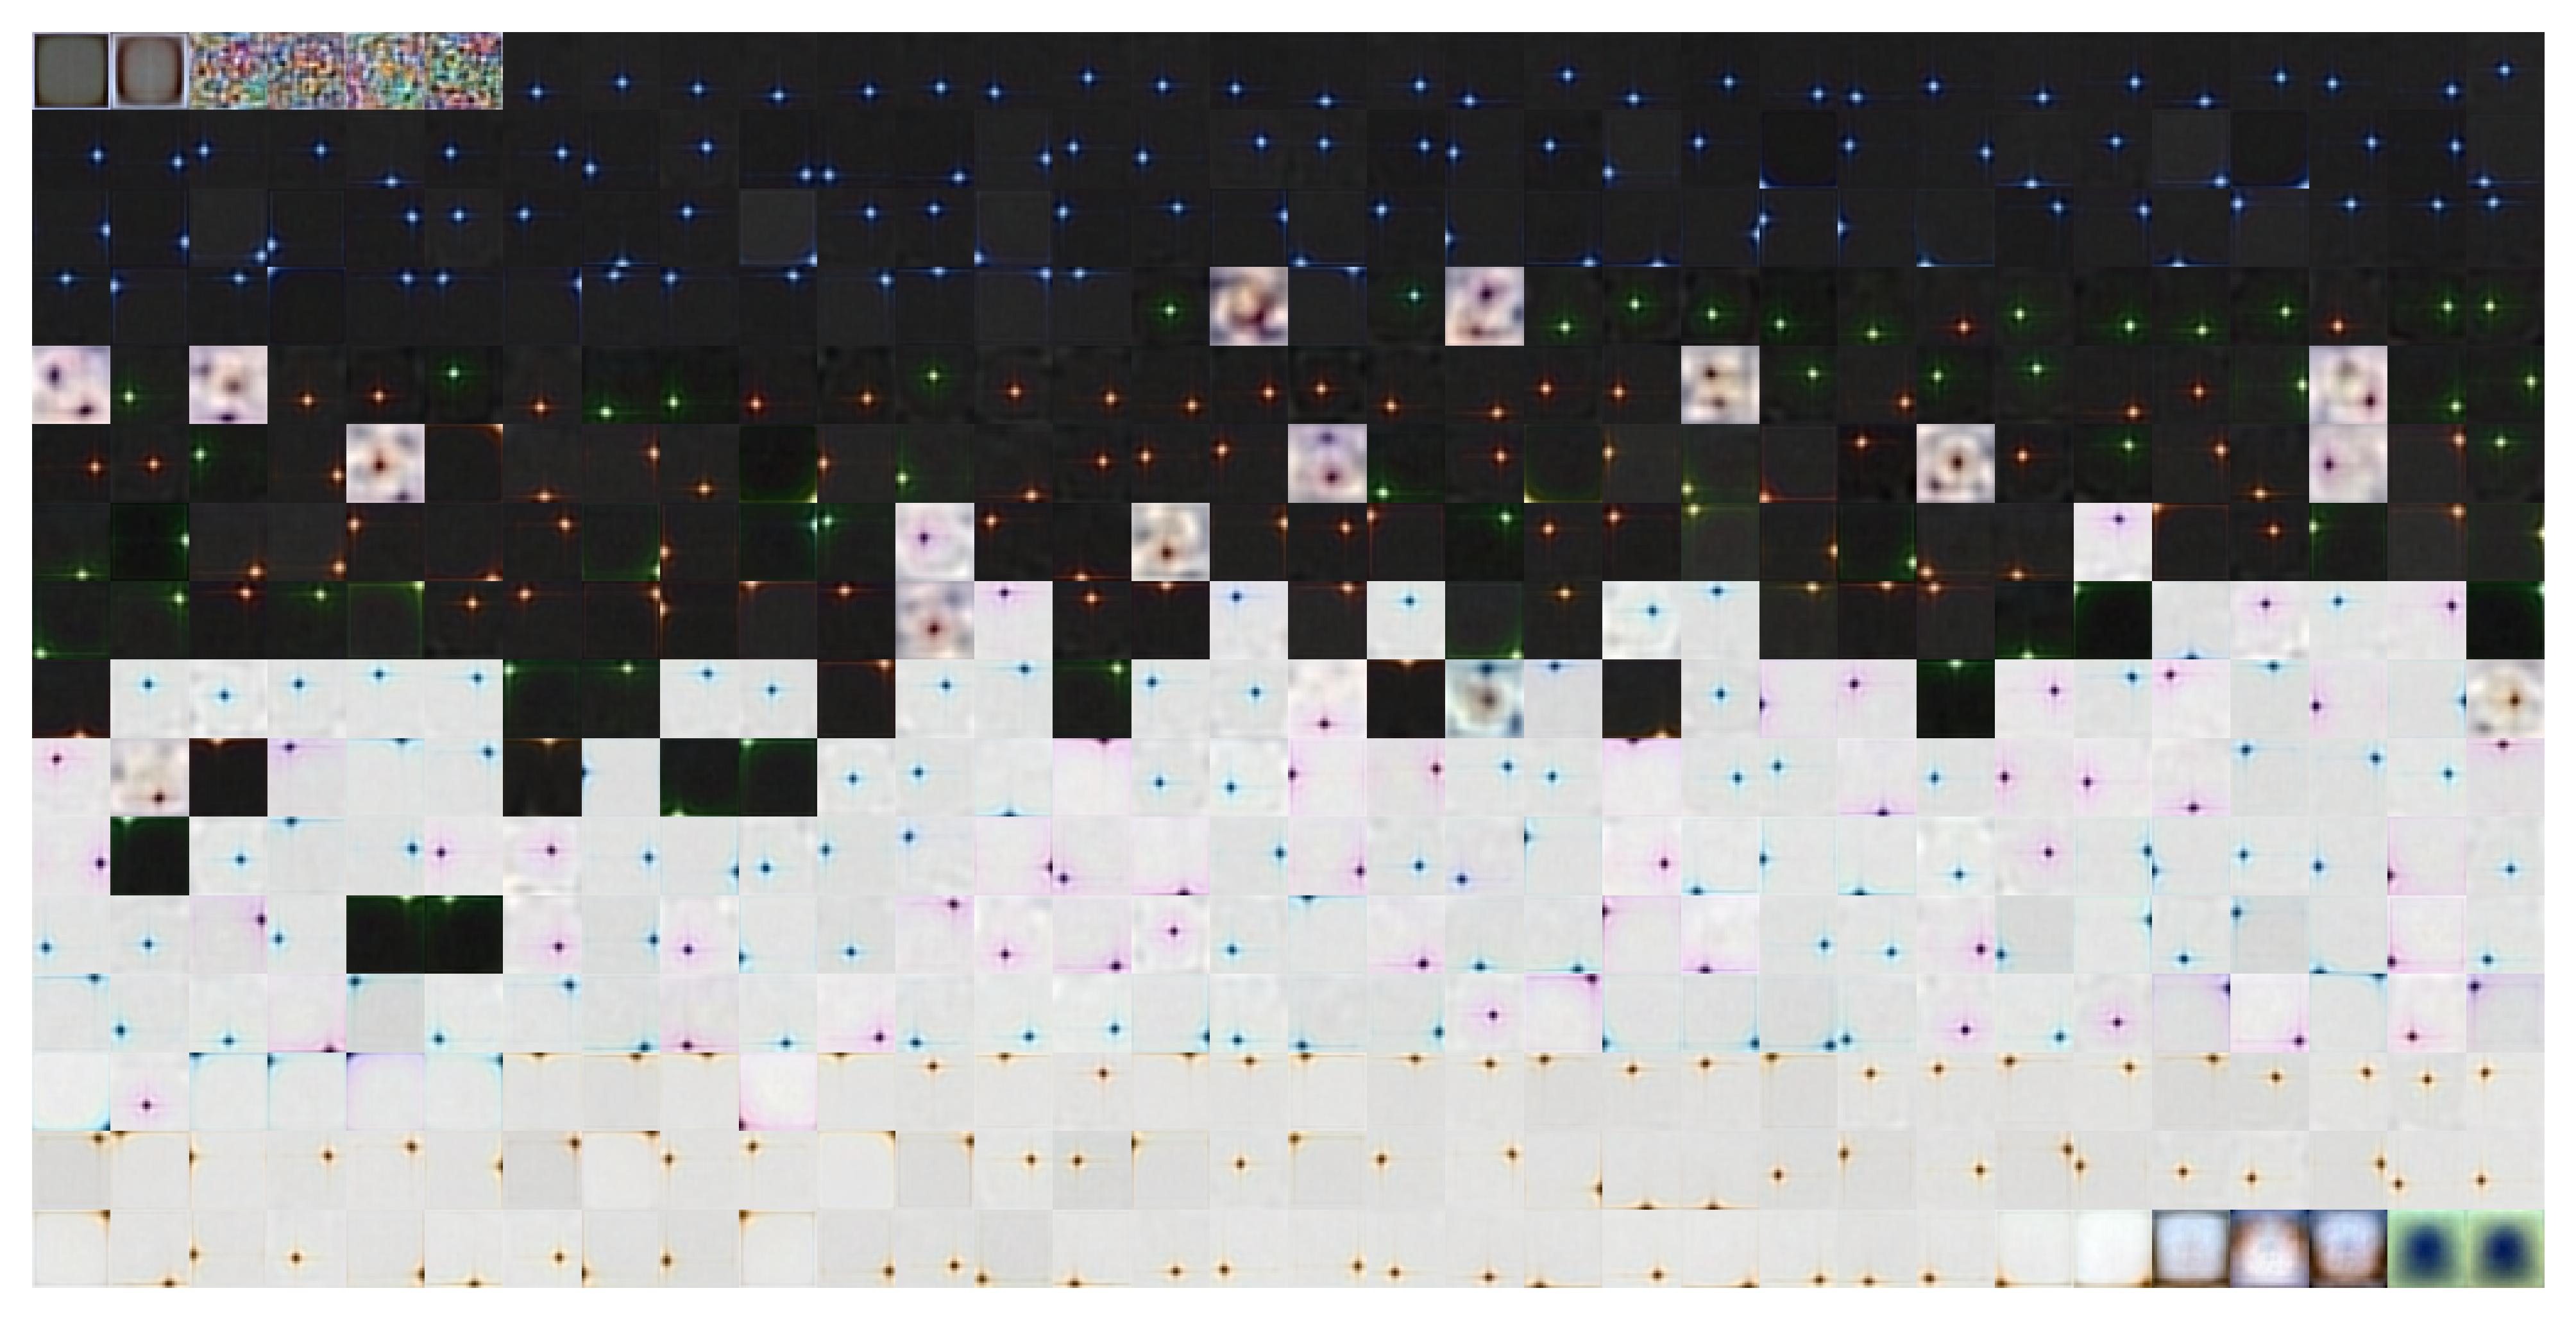

In [7]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
_ = tr.model.show(order=np.argsort(u0), nrows=16, dpi=500)

In [8]:
tr.cfg.batch_size = 1000
tr.setup_data()

In [9]:
%%time


seq_total = 500

true, pred = [], []
for x, *_ in tqdm(iter(tr.dl_vld)):
    # xtract
    output = tr.model.xtract_ftr(
        feeder=tr.get_feeder(tr.to(x)),
        seq=range(seq_total),
        return_extras=['conditional'],
    ).stack()
    
    true.append(tonp(x.flatten(start_dim=1)))
    conditional = output['conditional'][str(seq_total - 1)]
    pred.append(tonp(conditional.loc))

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true, pred = cat_map([true, pred])
error = true - pred
error.shape

100%|███████████████████████████████████████████| 50/50 [01:07<00:00,  1.35s/it]


CPU times: user 43.8 s, sys: 0 ns, total: 43.8 s
Wall time: 1min 12s


(50000, 3072)

In [10]:
# order: high contrast
var = np.var(true, axis=1)
order = np.argsort(var)[::-1]

# get whitened data
# _, whitened, _ = make_dataset('Kyoto16', device)
# whitened = whitened.tensors[0].flatten(start_dim=1)
# whitened.shape

In [11]:
a = true.reshape((-1, *tr.model.cfg.input_sz))
a = np.transpose(a, axes=(0, 2, 3, 1))

b = pred.reshape((-1, *tr.model.cfg.input_sz))
b = np.transpose(b, axes=(0, 2, 3, 1))

c = a - b

a.shape, b.shape

((50000, 32, 32, 3), (50000, 32, 32, 3))

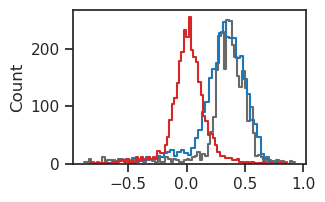

In [12]:
histplot(a[3].ravel(), color='dimgrey');
histplot(b[3].ravel(), color='C0');
histplot(c[3].ravel(), color='C3');

In [13]:
a_plot = np.clip((1 + a) / 2, a_min=0, a_max=1.0)
b_plot = np.clip((1 + b) / 2, a_min=0, a_max=1.0)
c_plot = np.clip((1 + c) / 2, a_min=0, a_max=1.0)

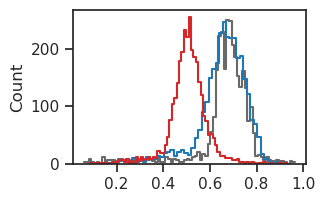

In [14]:
histplot(a_plot[3].ravel(), color='dimgrey');
histplot(b_plot[3].ravel(), color='C0');
histplot(c_plot[3].ravel(), color='C3');

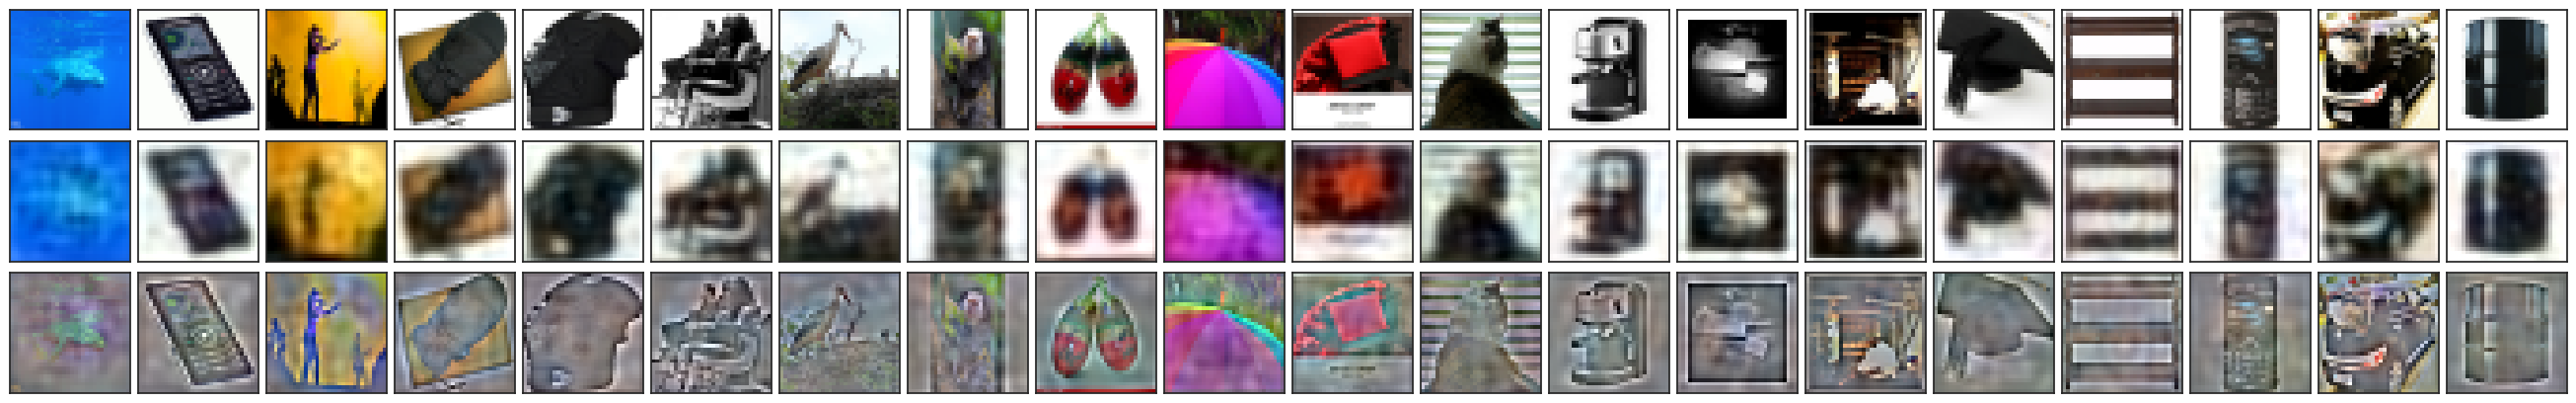

In [15]:
rng = get_rng(0)

ncols = 20
selected_ids = rng.choice(order[:500], ncols, replace=False)
fig, axes = create_figure(3, ncols, (1.3 * ncols, 4), 'all', 'all')

for i in range(ncols):
    img_i = selected_ids[i]
    axes[0, i].imshow(a_plot[img_i])
    axes[1, i].imshow(b_plot[img_i])
    axes[2, i].imshow(c_plot[img_i])

remove_ticks(axes, False)

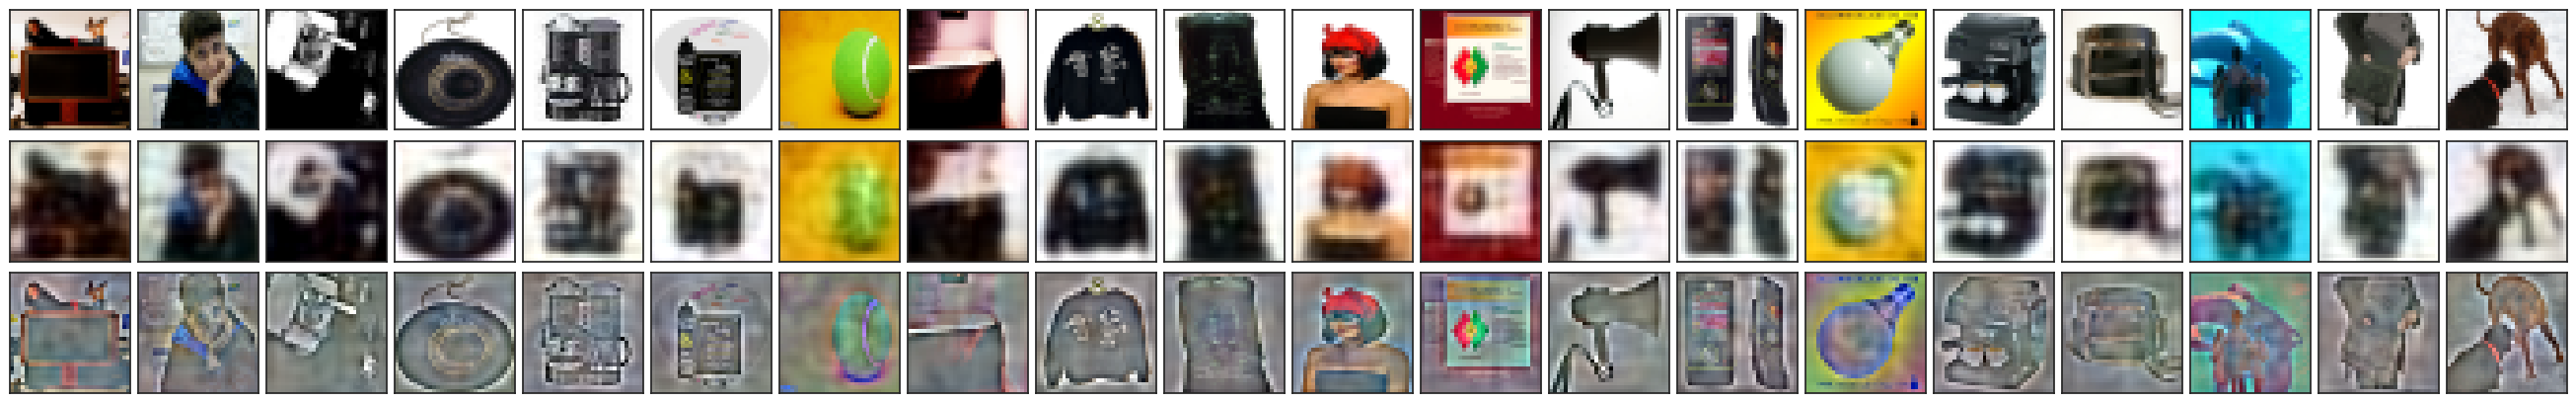

In [16]:
selected_ids = rng.choice(order[:500], ncols, replace=False)
fig, axes = create_figure(3, ncols, (1.3 * ncols, 4), 'all', 'all')

for i in range(ncols):
    img_i = selected_ids[i]
    axes[0, i].imshow(a_plot[img_i])
    axes[1, i].imshow(b_plot[img_i])
    axes[2, i].imshow(c_plot[img_i])

remove_ticks(axes, False)

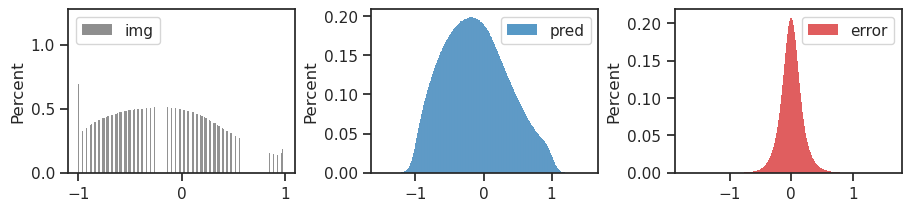

In [17]:
_plot_sample_hists()

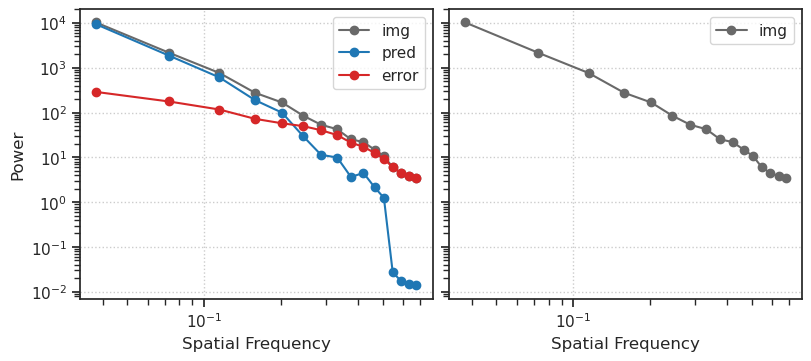

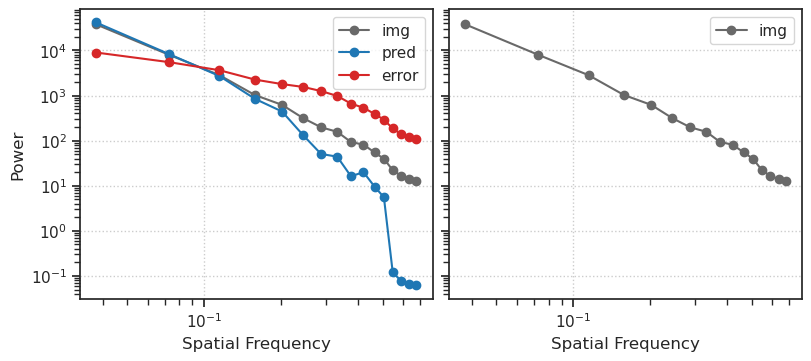

In [18]:
_plot_power_spectrum(normalize=False, add_whitened=False)
_plot_power_spectrum(normalize=True, add_whitened=False)

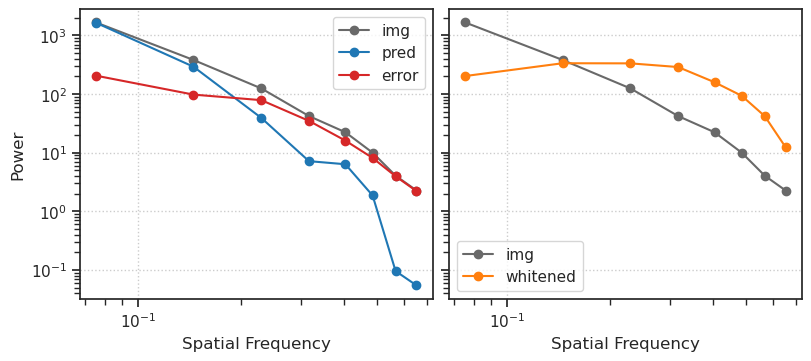

In [11]:
_plot_power_spectrum()

## Movie: first few t

```python
t in range(50)
```

In [59]:
# get whitened data
_, whitened, _ = make_dataset('Kyoto16', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened = whitened[torch.from_numpy(order.copy())]
whitened = whitened[:500]

error.shape, whitened.shape

(torch.Size([500, 256]), torch.Size([500, 256]))

In [60]:
# get stimulus
x = tr.dl_vld.dataset.tensors[0]
x = x[torch.from_numpy(order.copy())]
x = x[:500]
true = x.flatten(start_dim=1)

x.shape, true.shape

(torch.Size([500, 1, 16, 16]), torch.Size([500, 256]))

In [61]:
# xtract
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(x),
    seq=range(1000),
    return_extras=['conditional'],
).stack()

t = 0

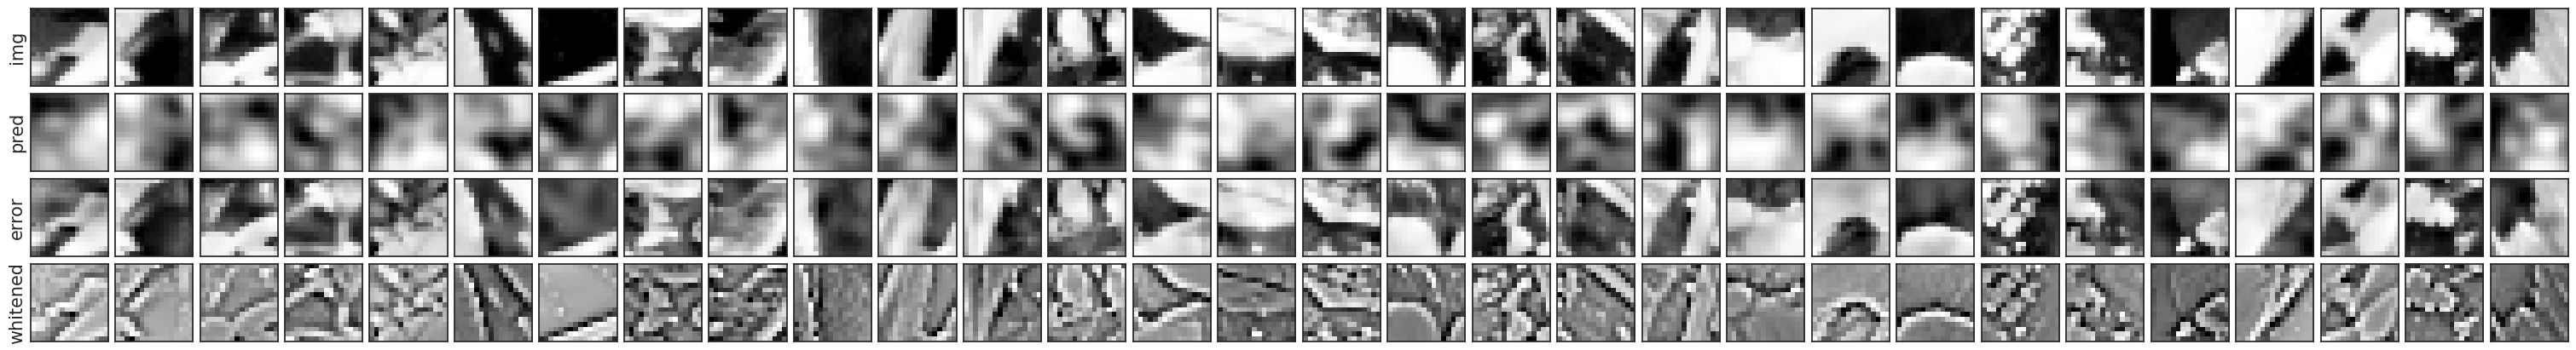

t = 1

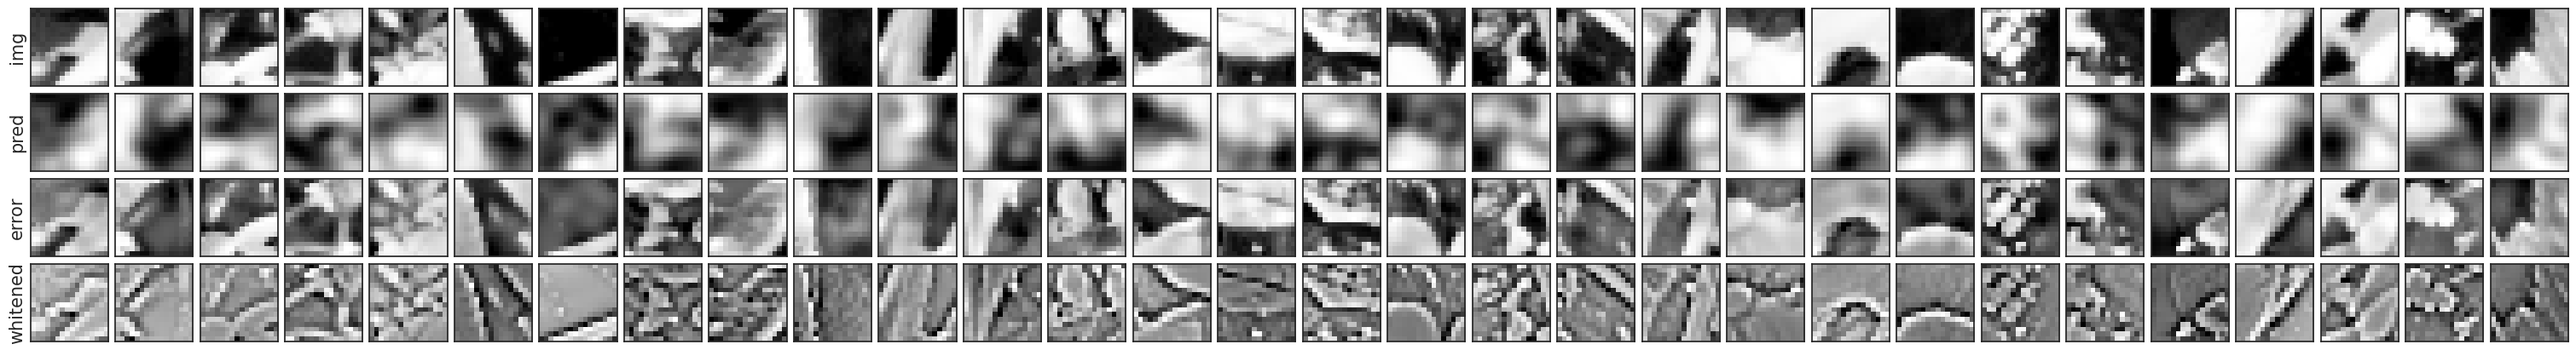

t = 2

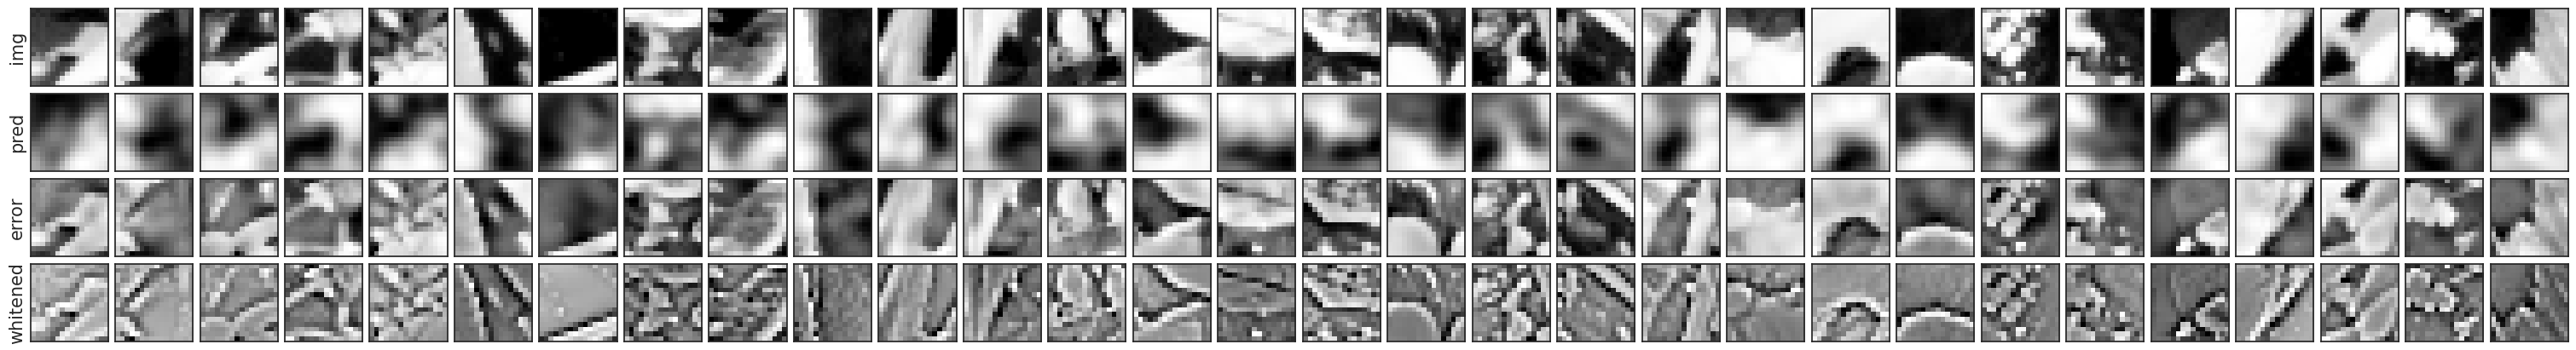

t = 3

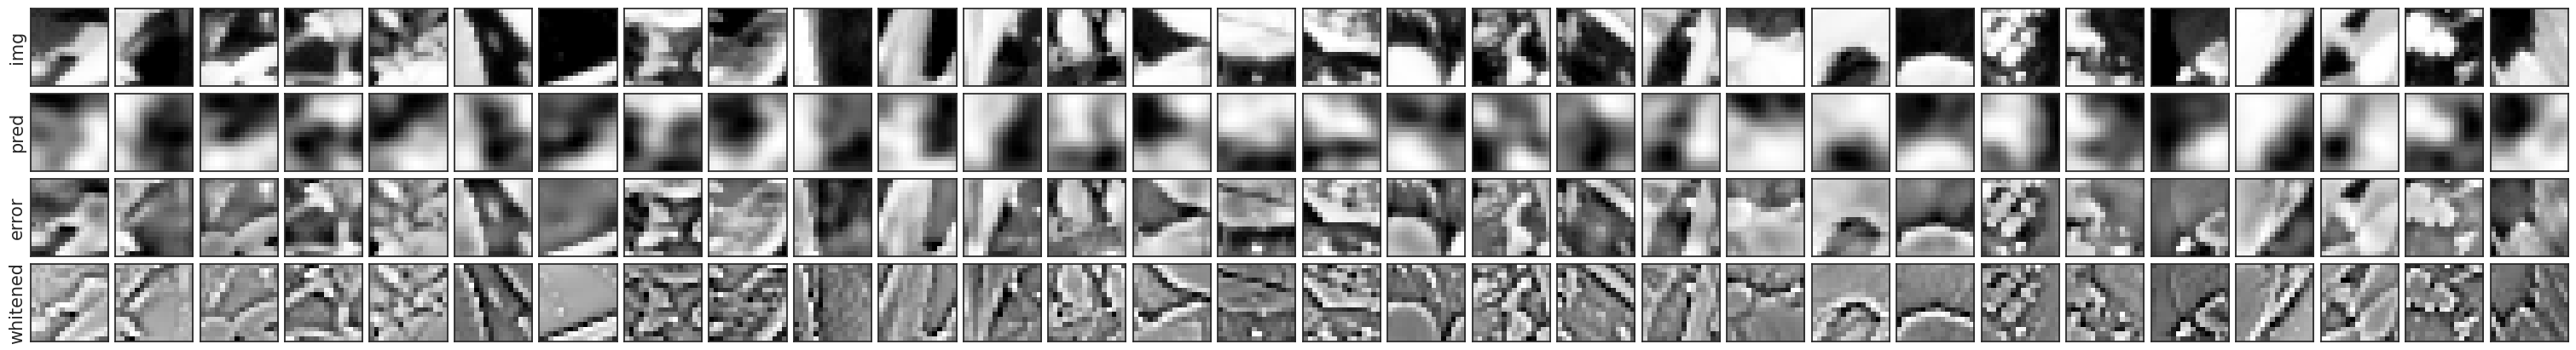

t = 4

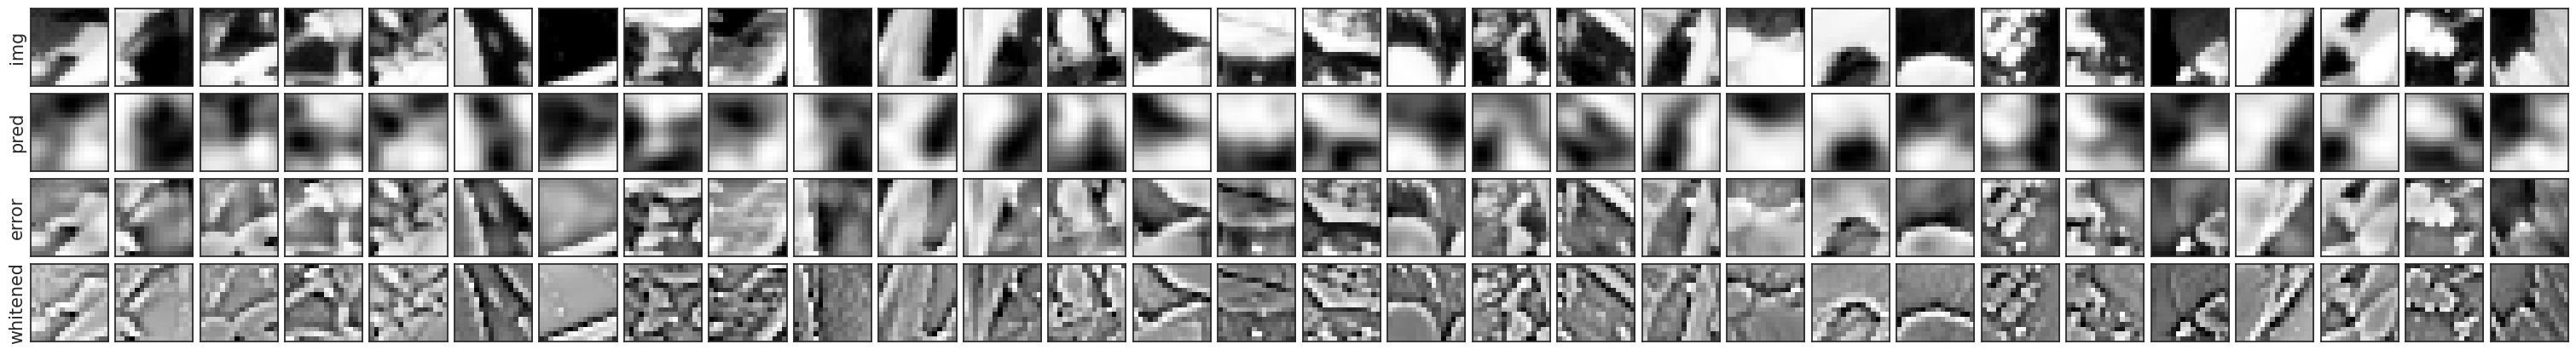

t = 5

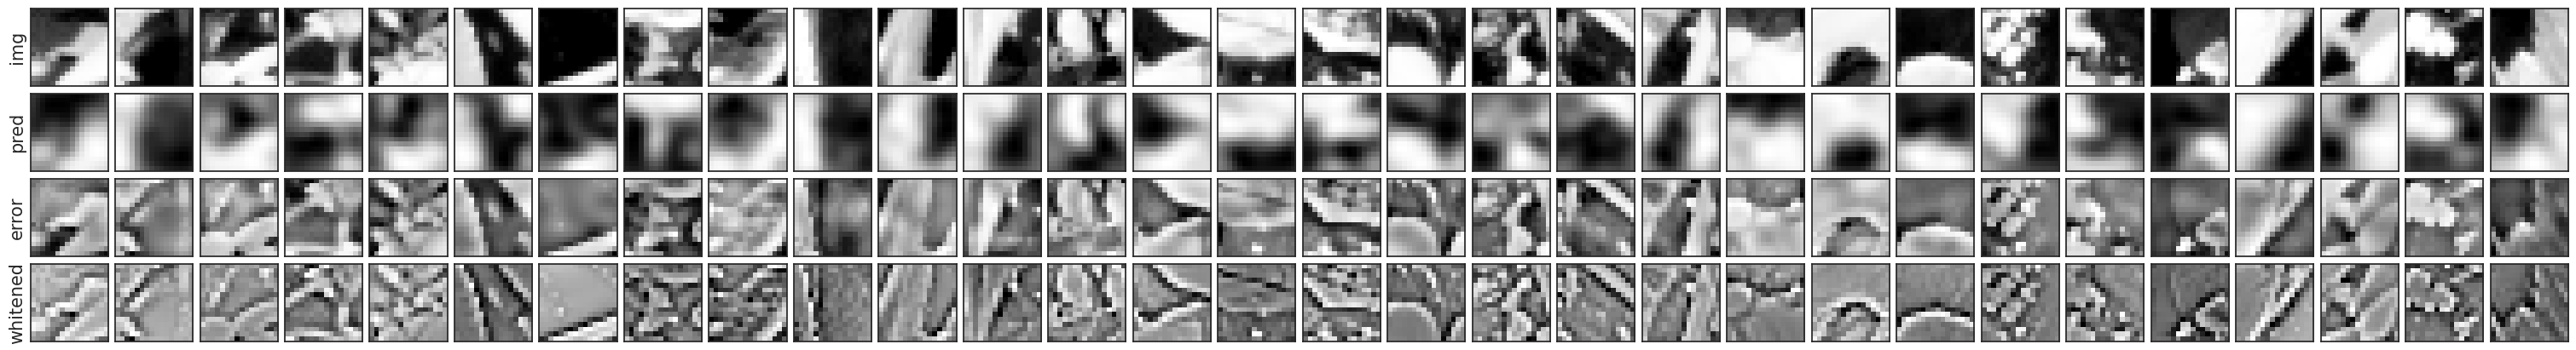

t = 6

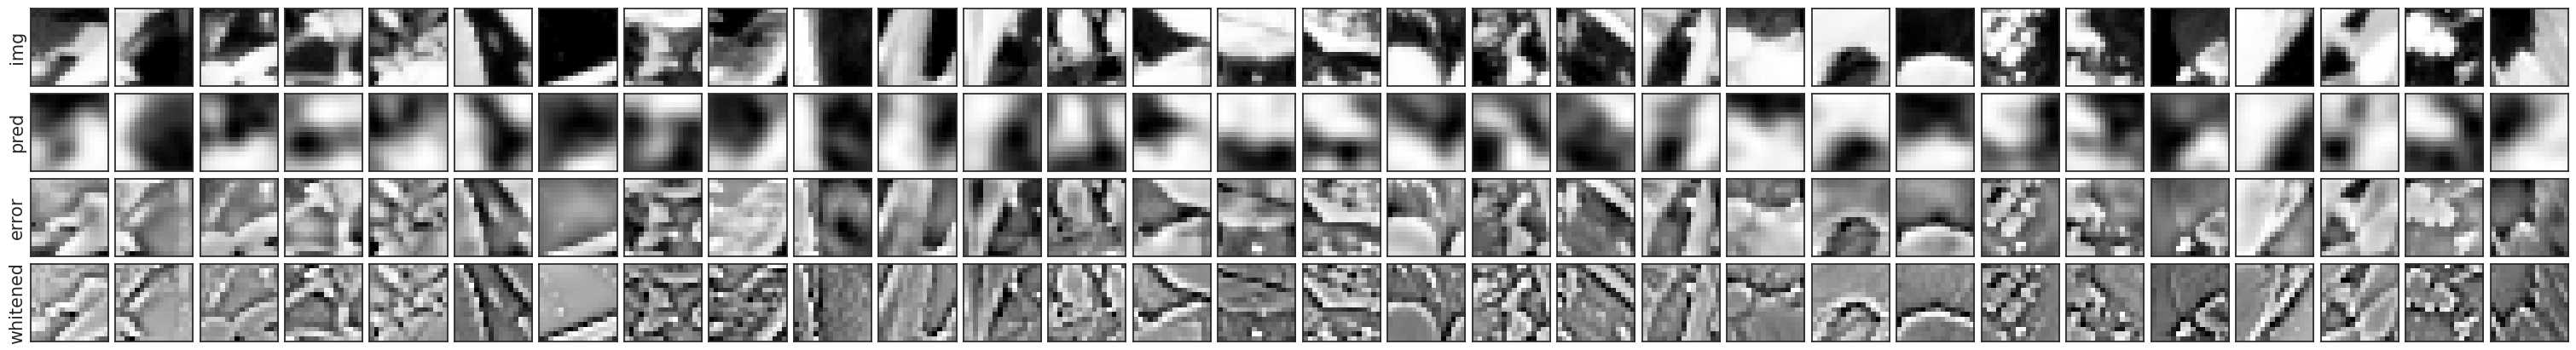

t = 7

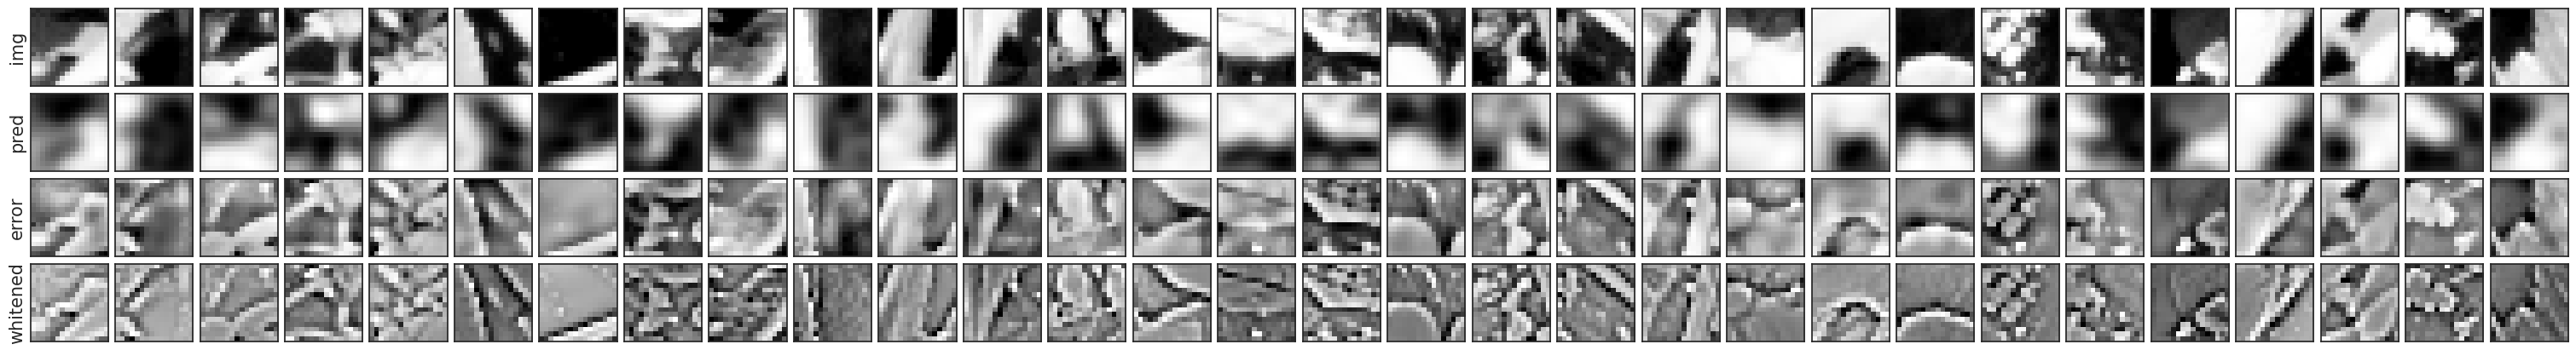

t = 8

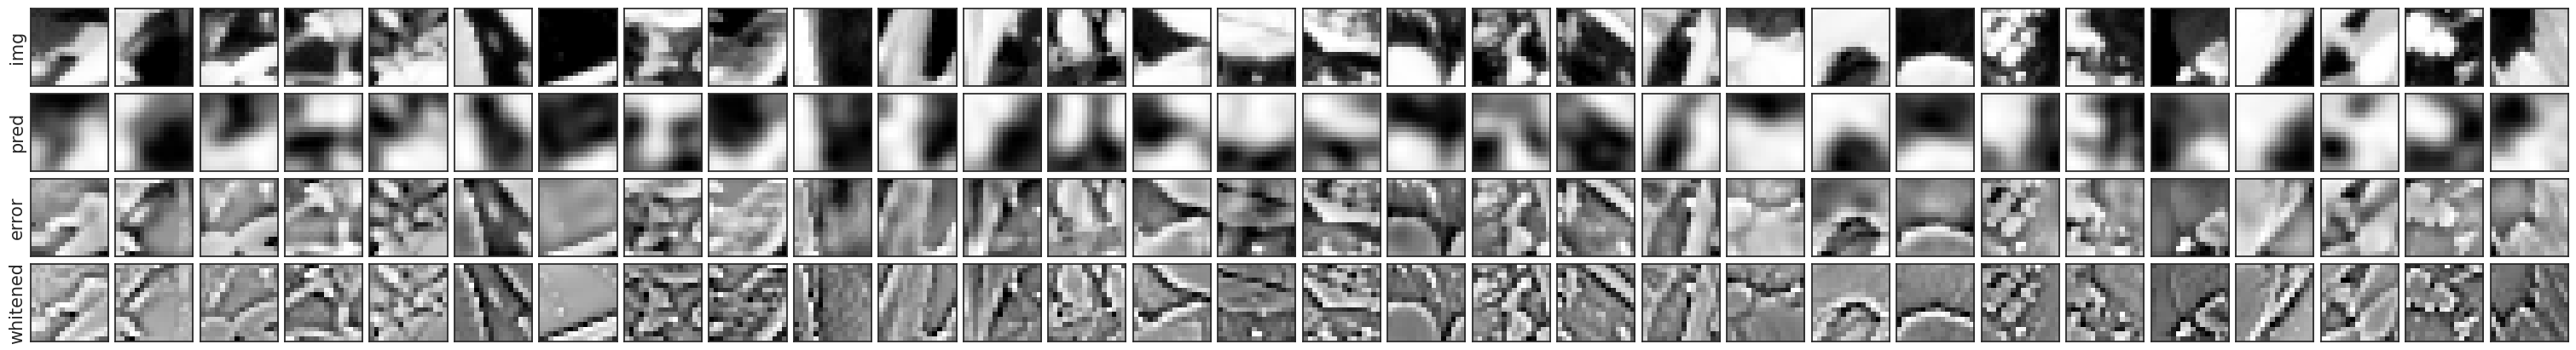

t = 9

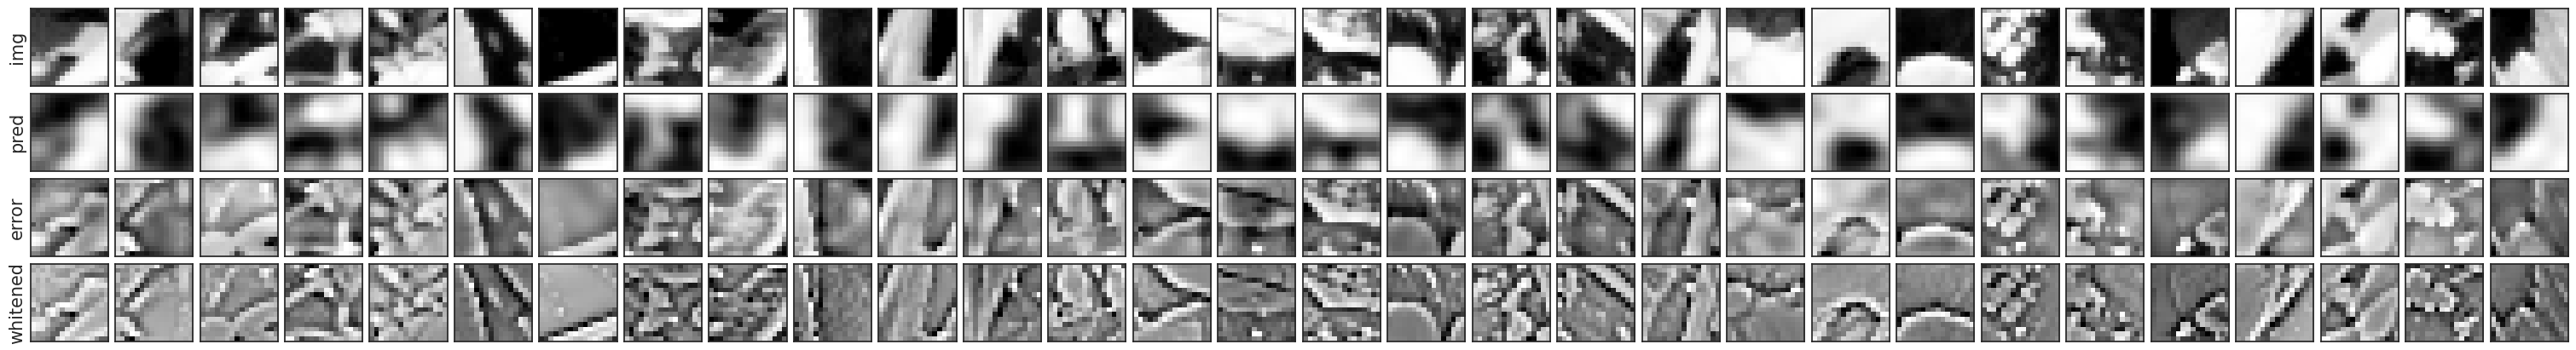

t = 10

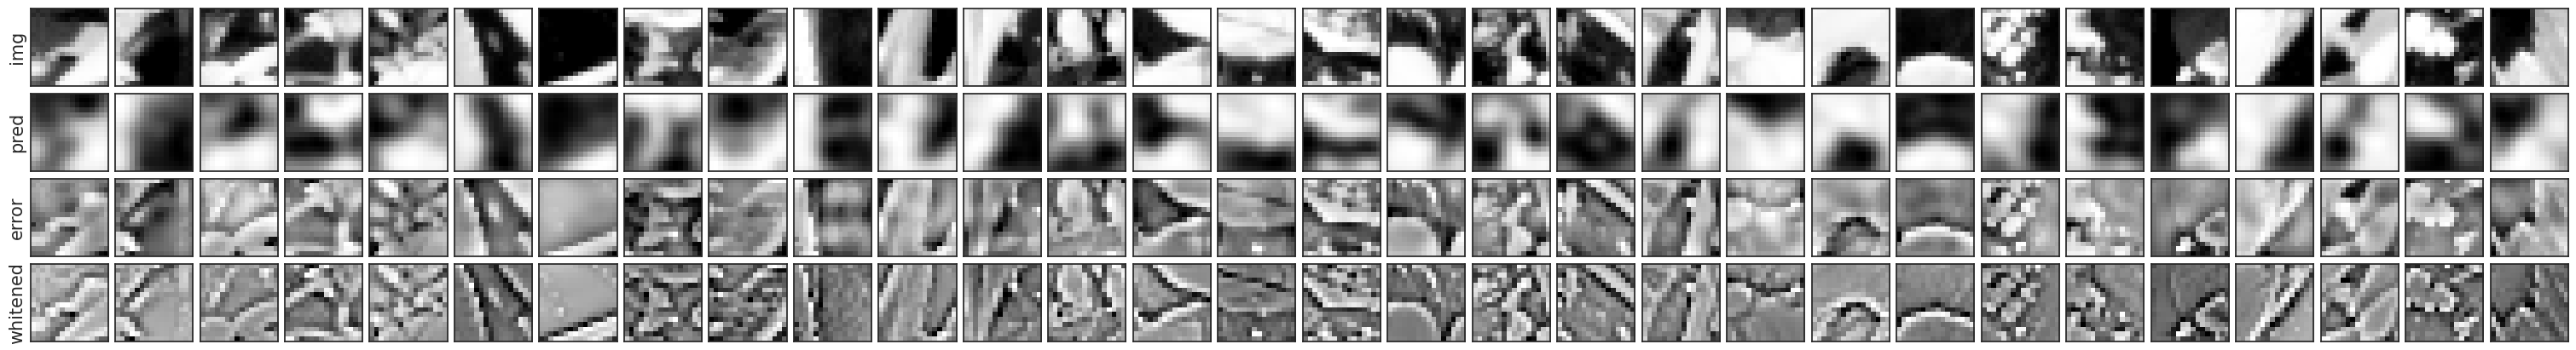

t = 11

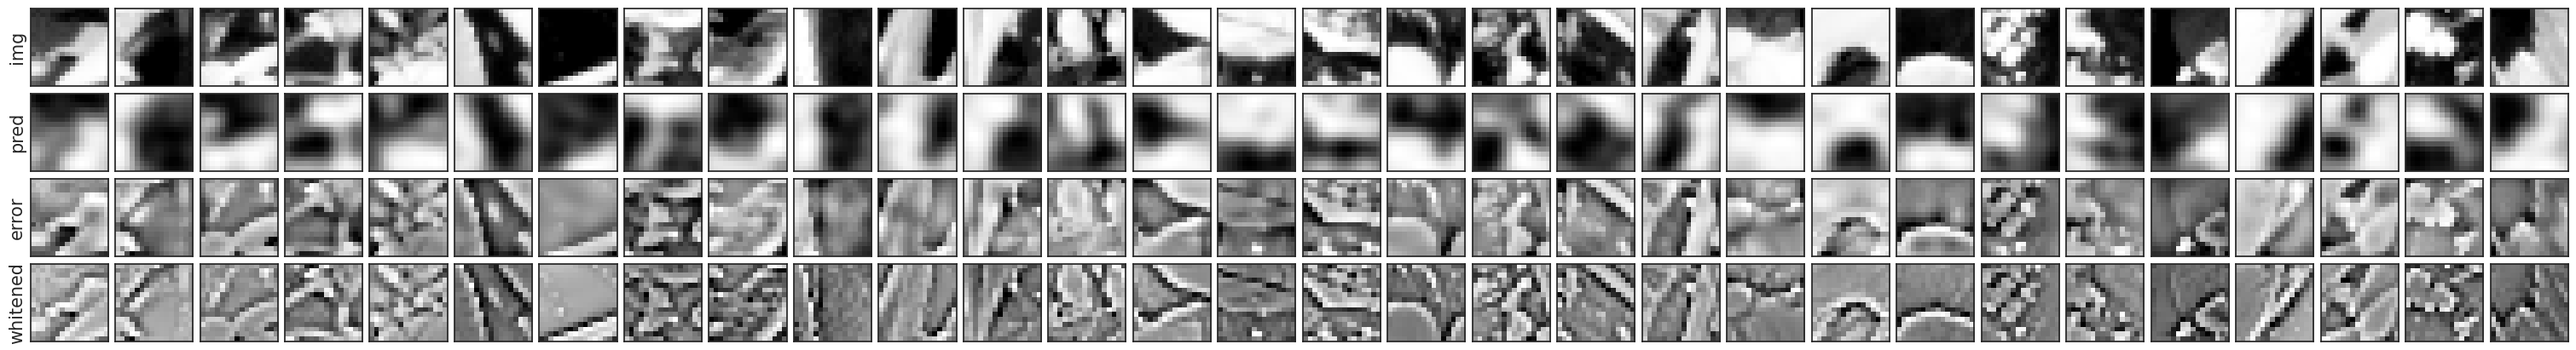

t = 12

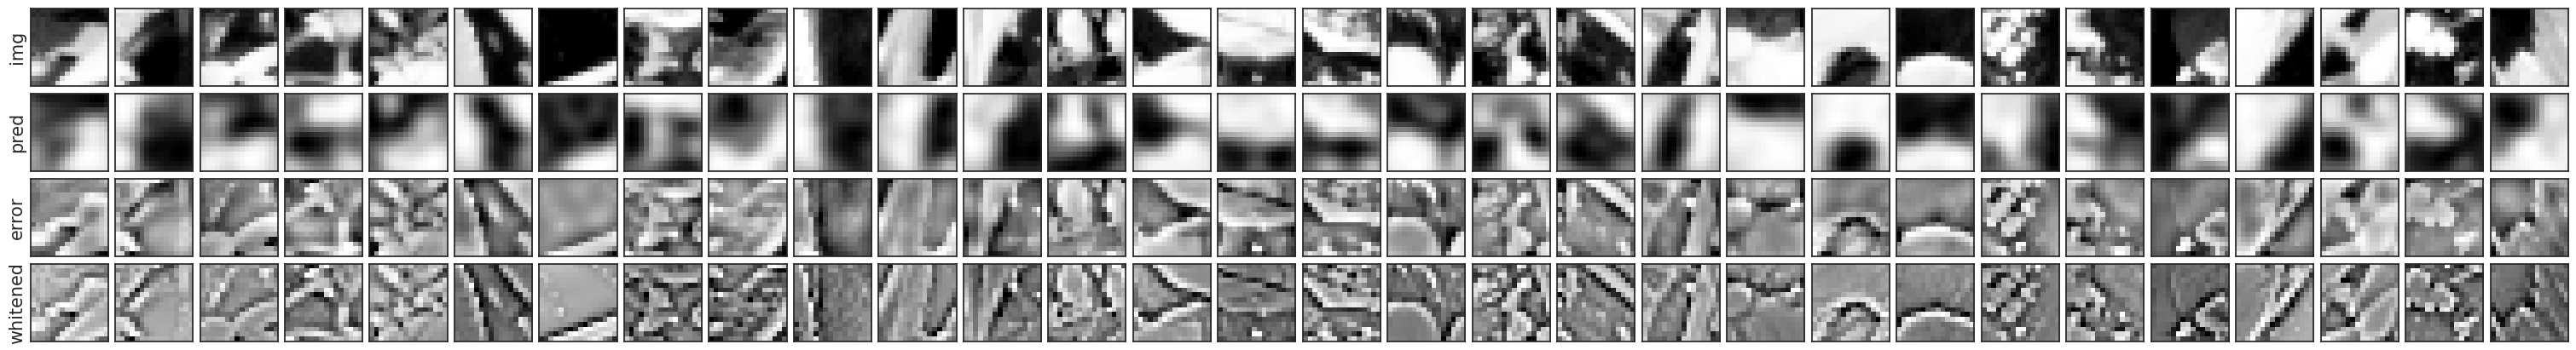

t = 13

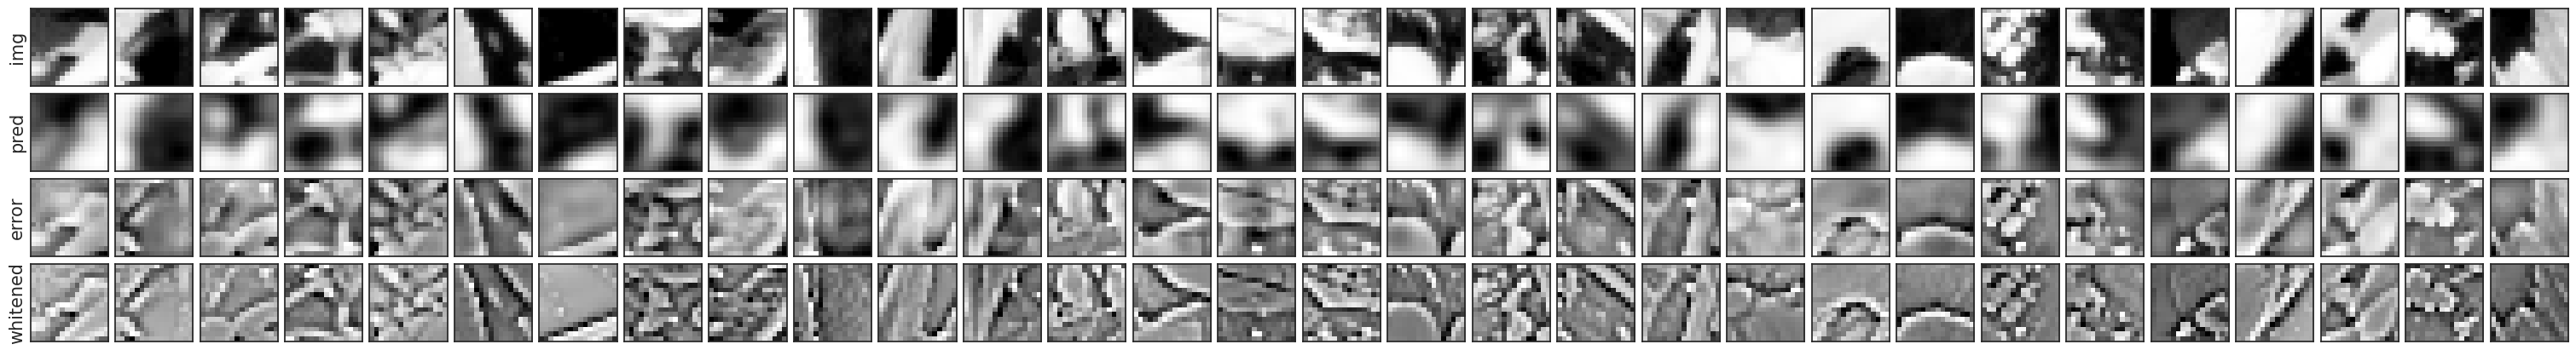

t = 14

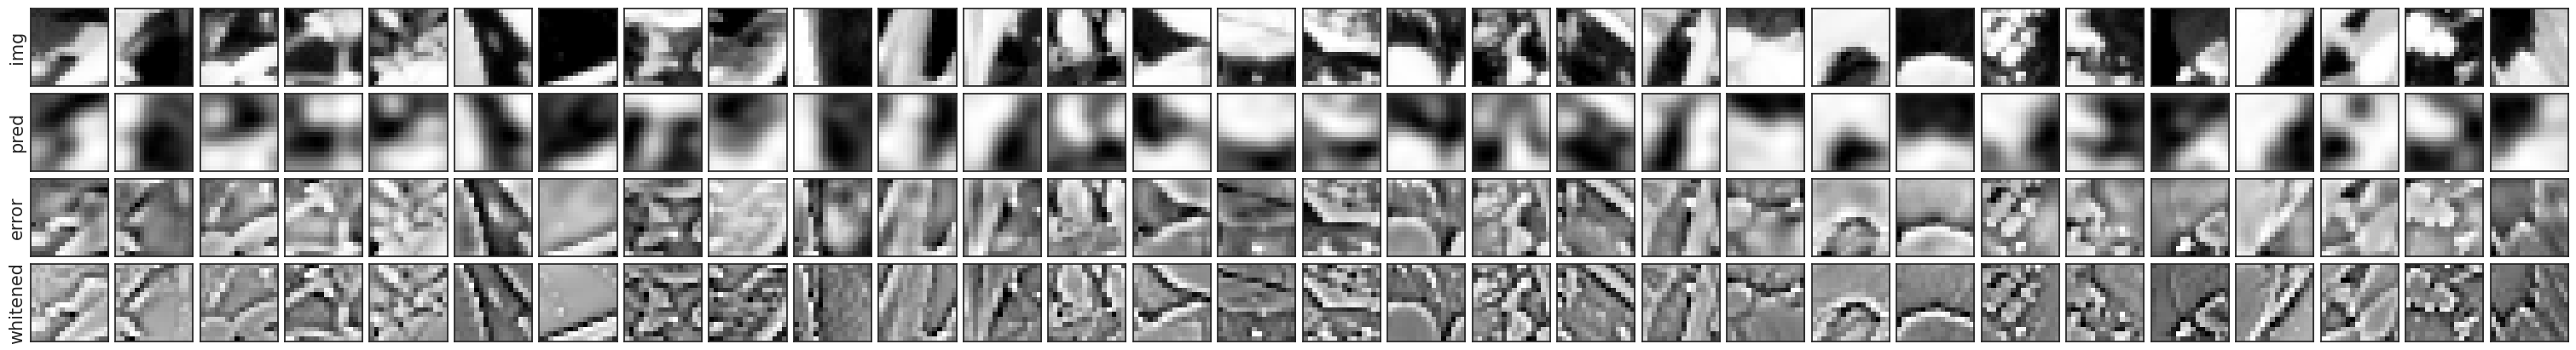

t = 15

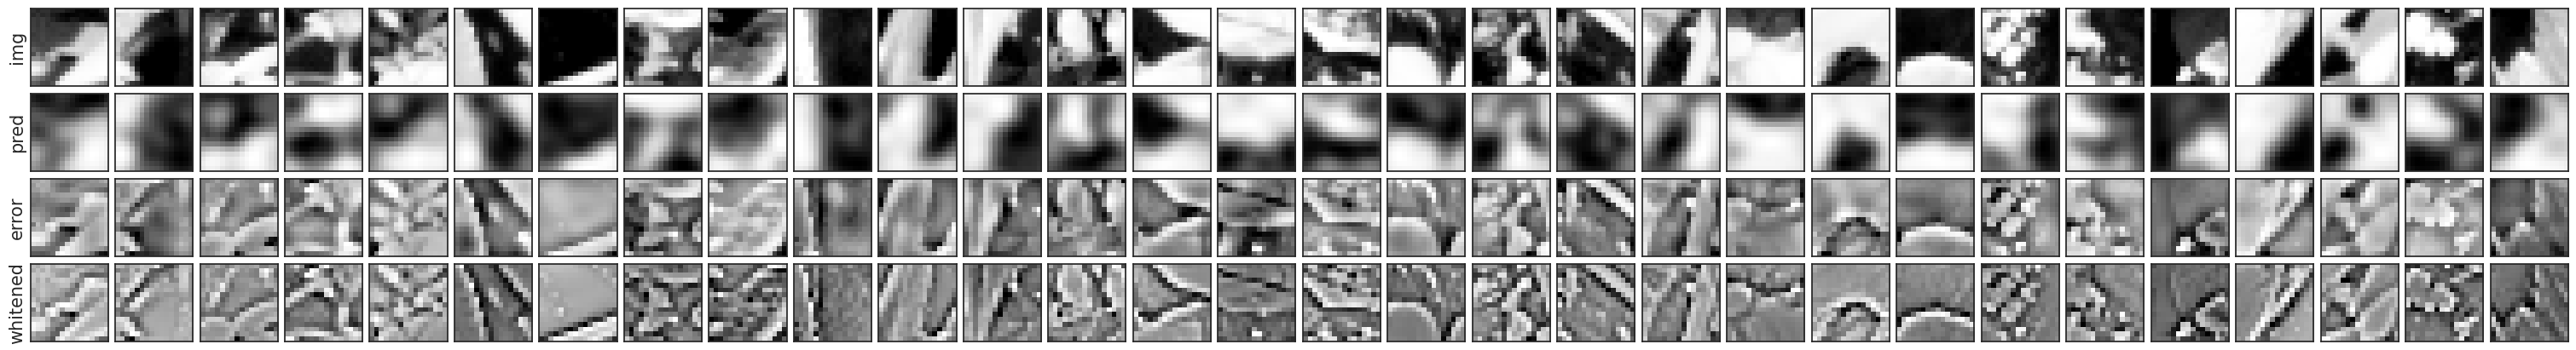

t = 16

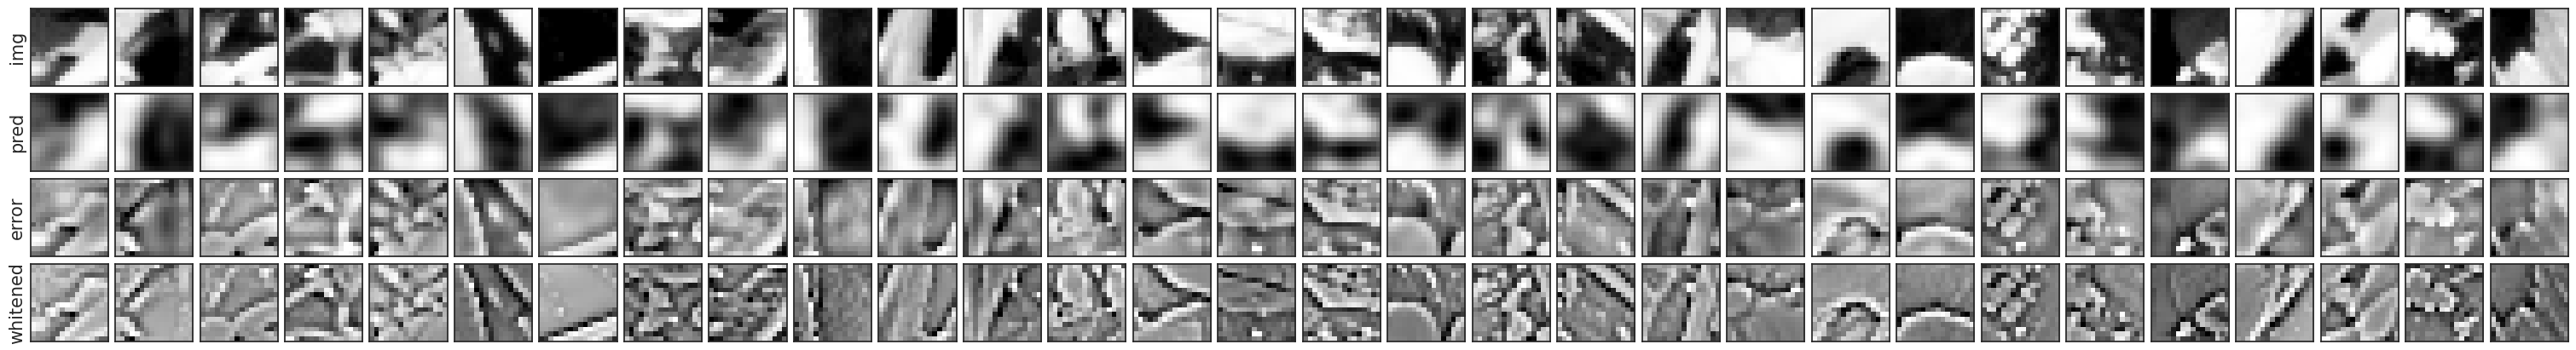

t = 17

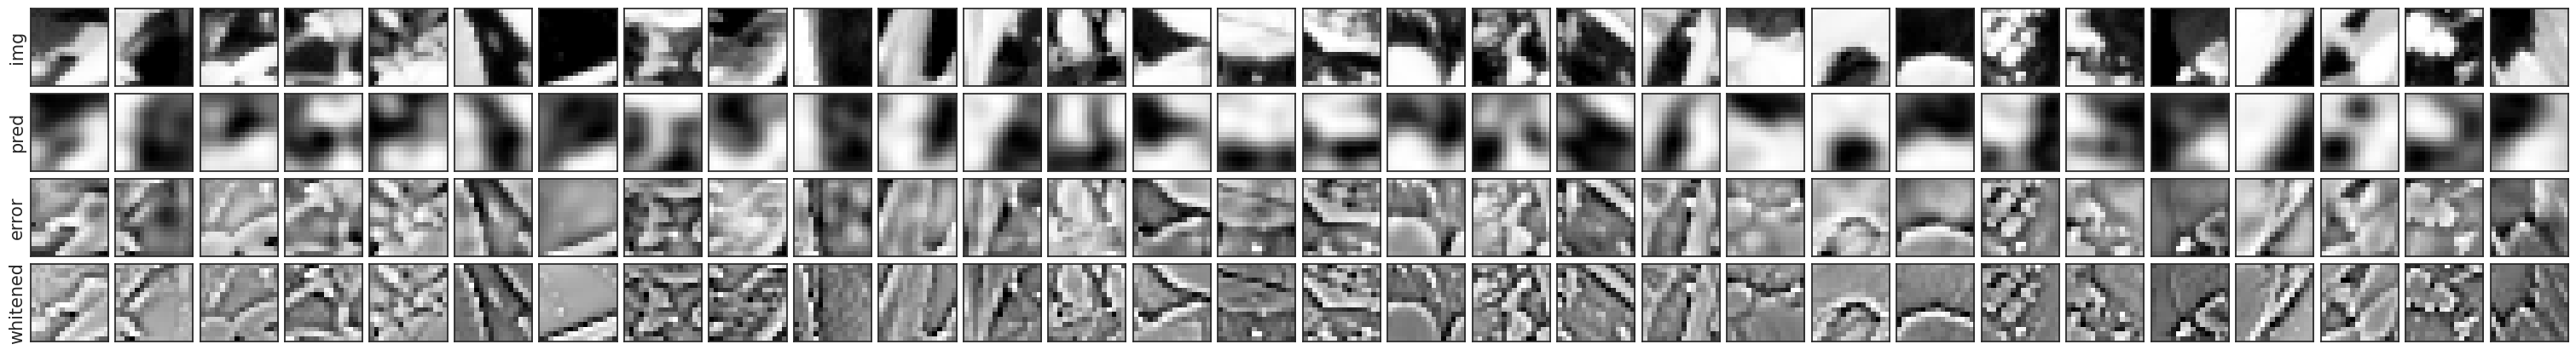

t = 18

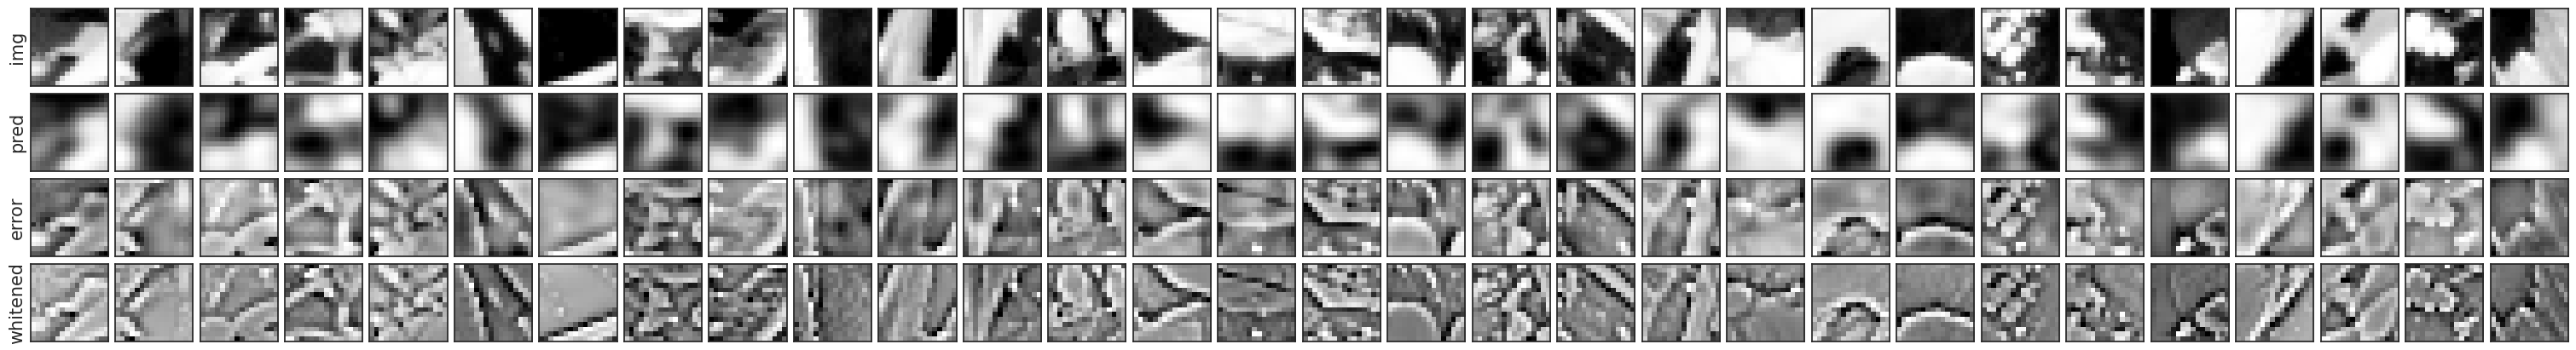

t = 19

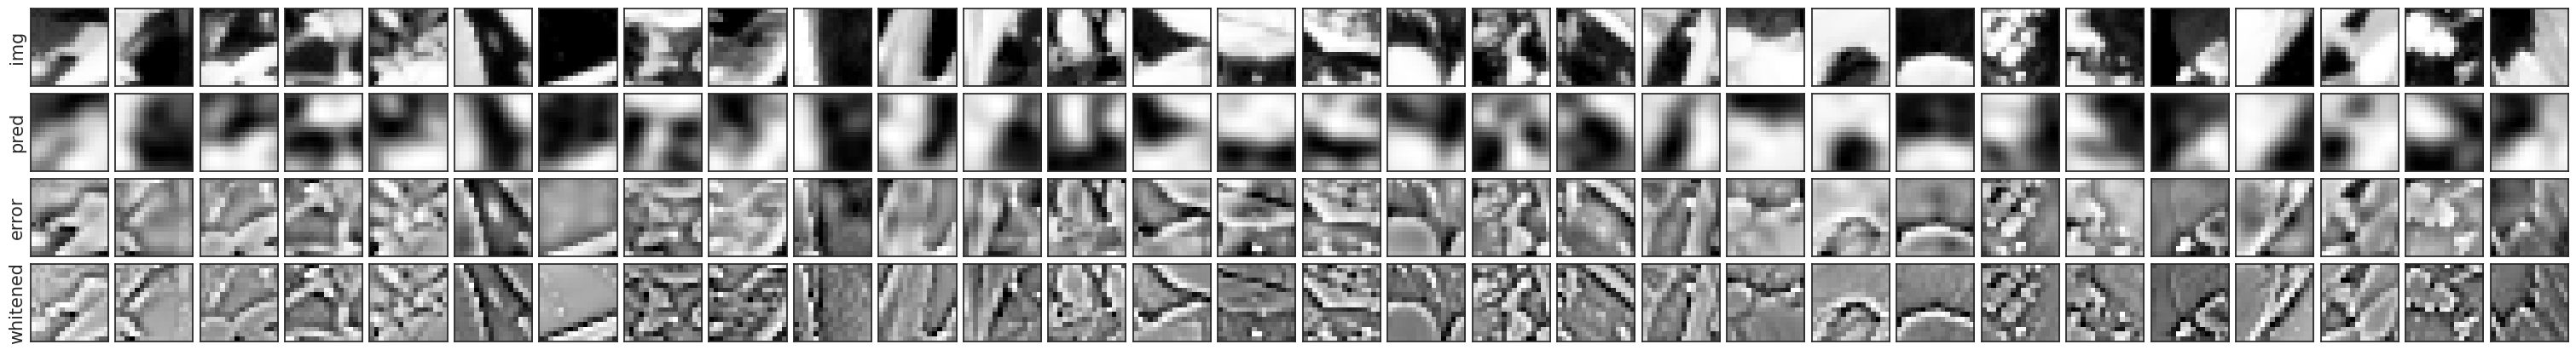

t = 20

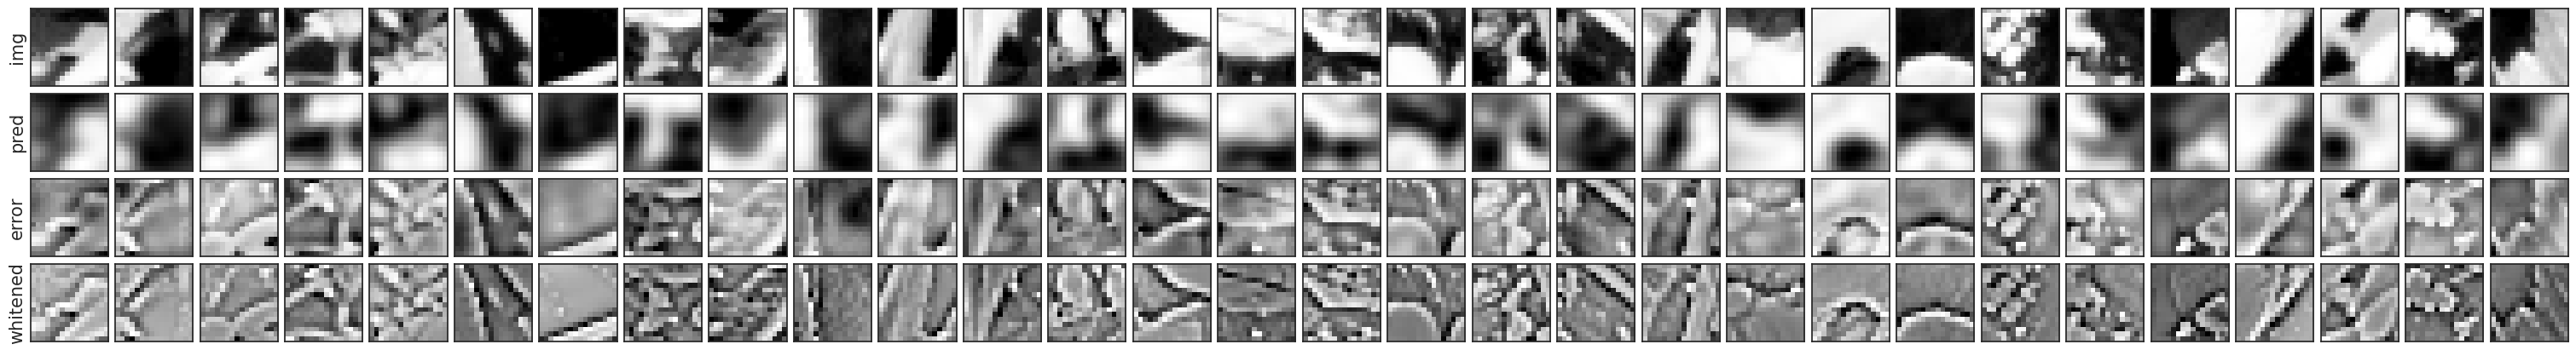

t = 21

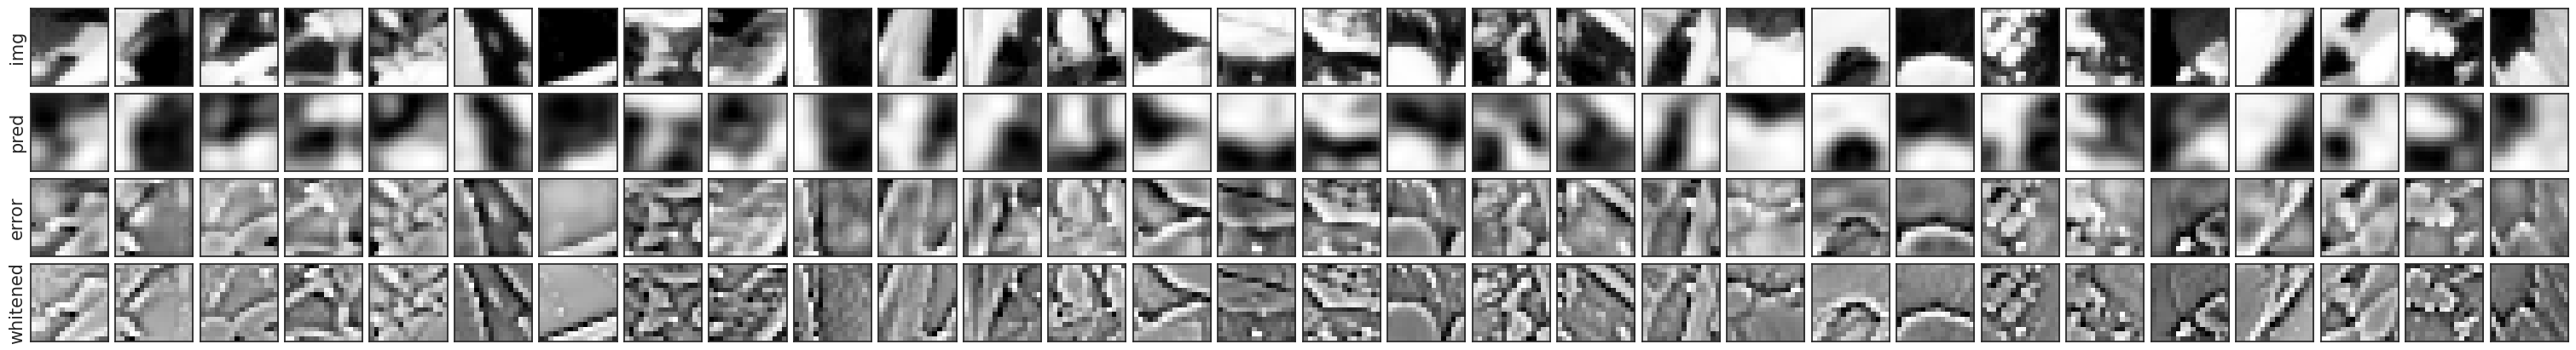

t = 22

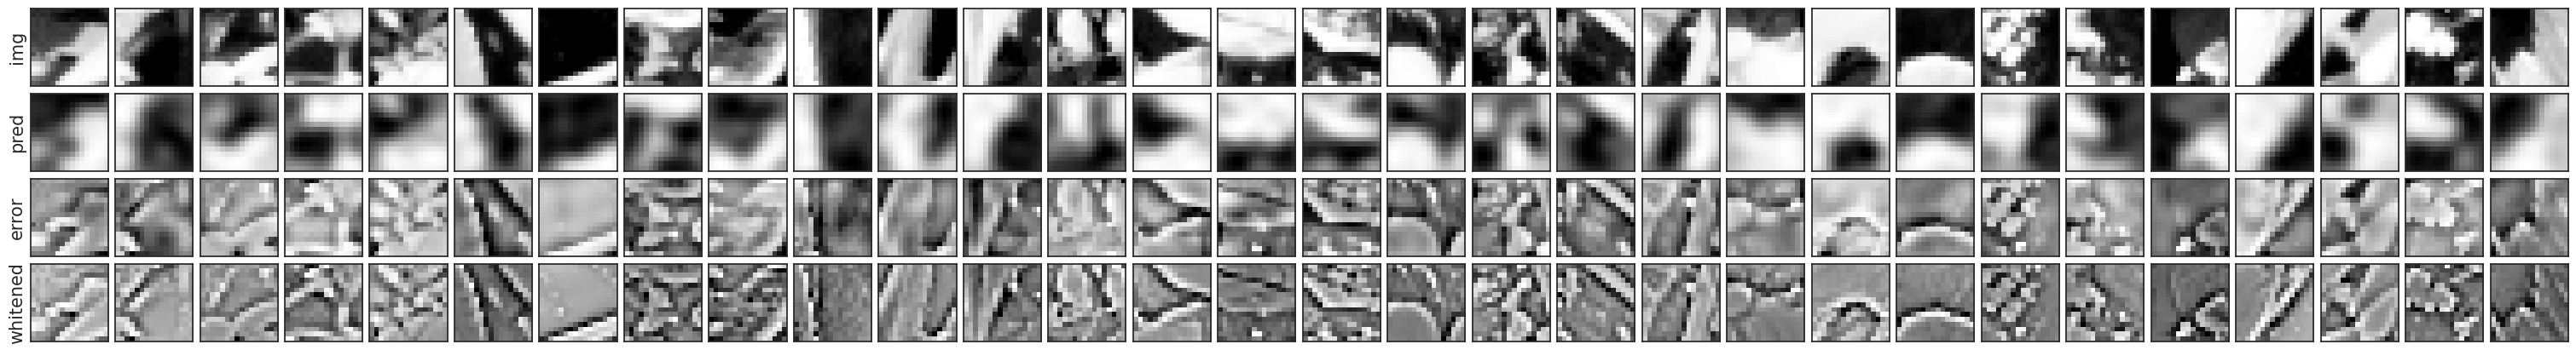

t = 23

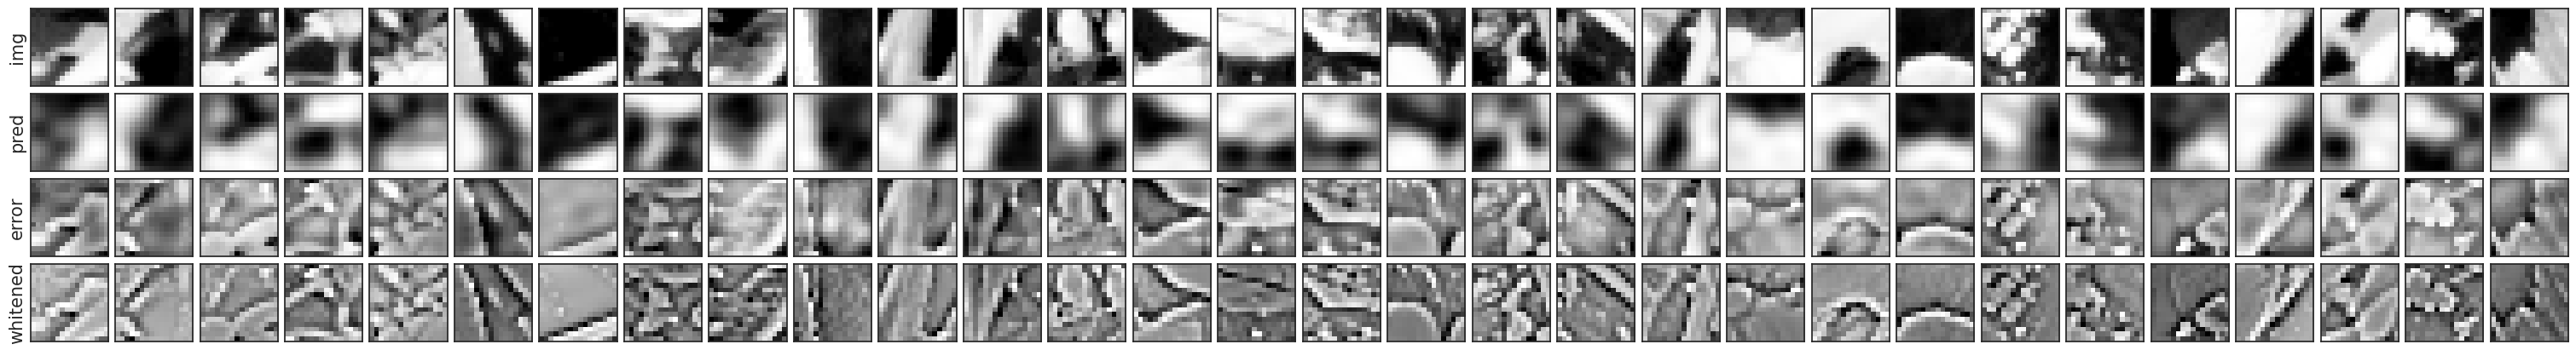

t = 24

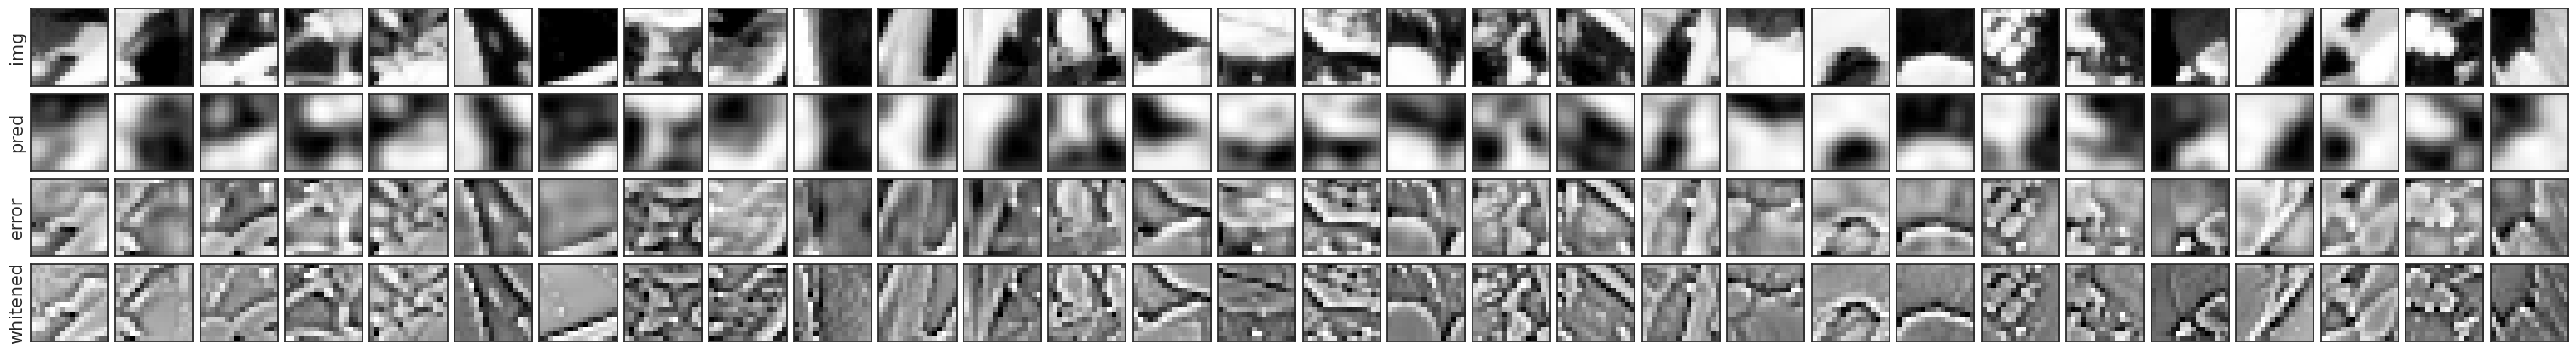

t = 25

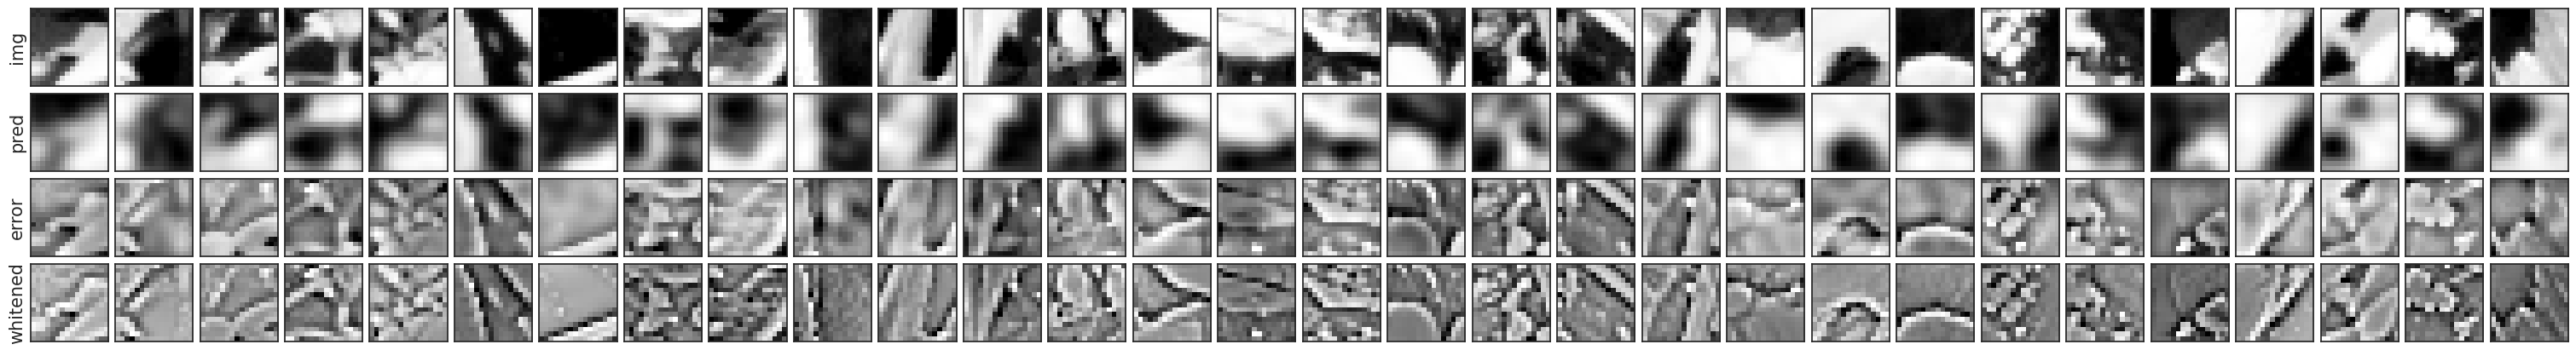

t = 26

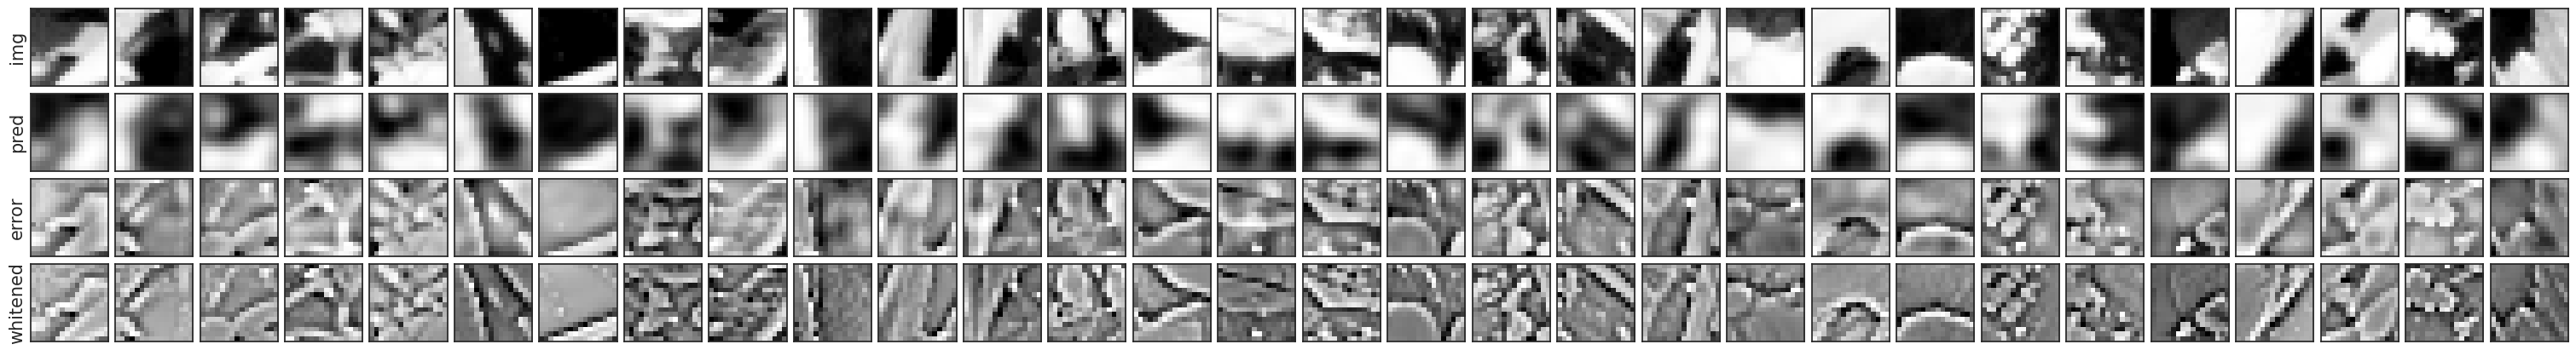

t = 27

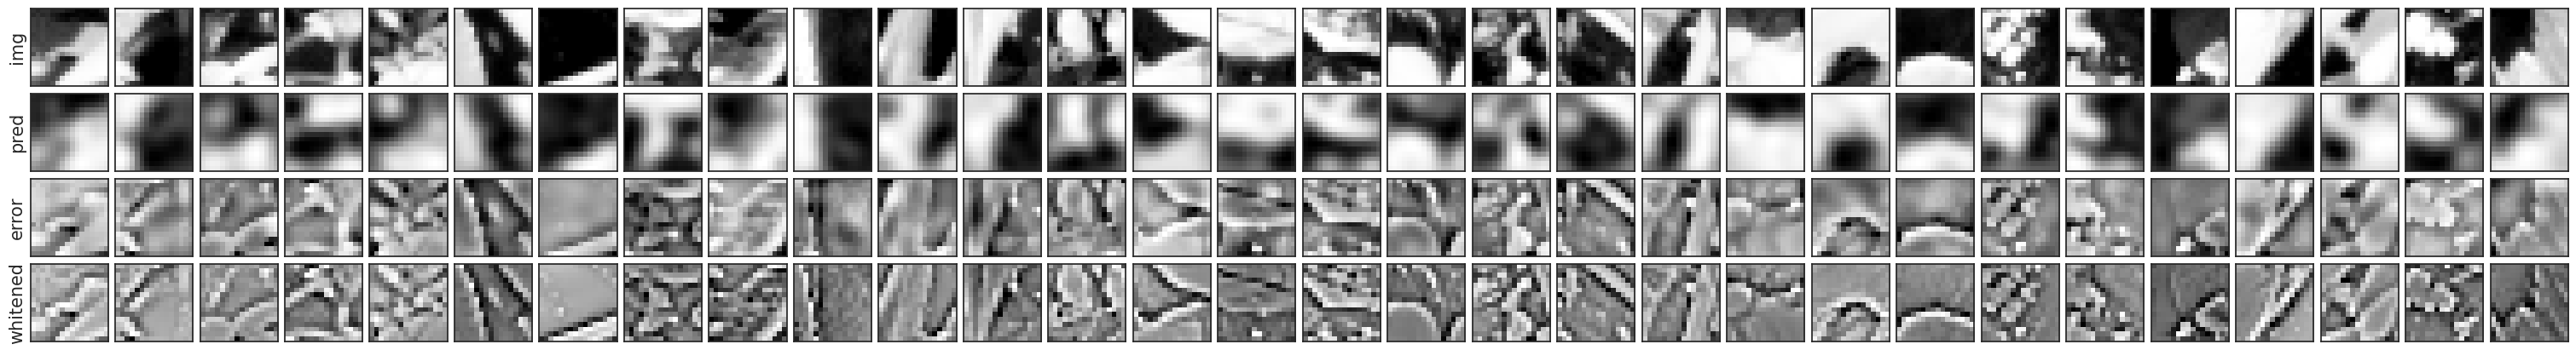

t = 28

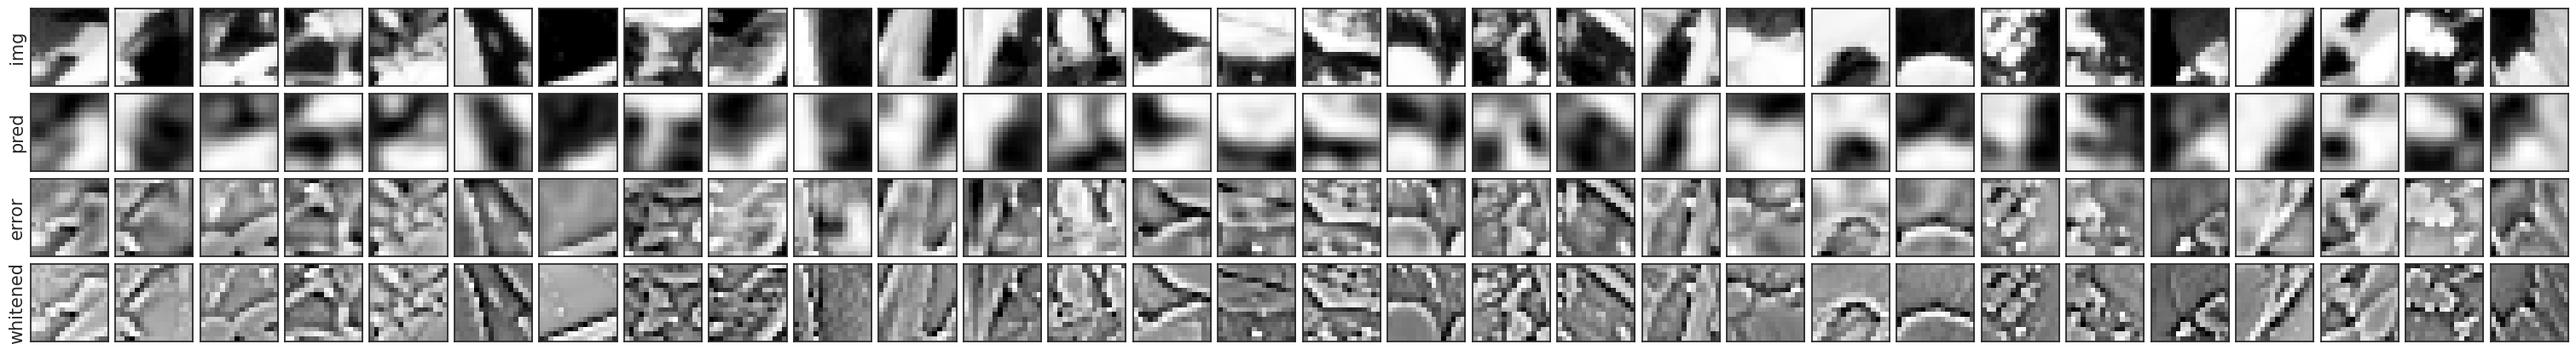

t = 29

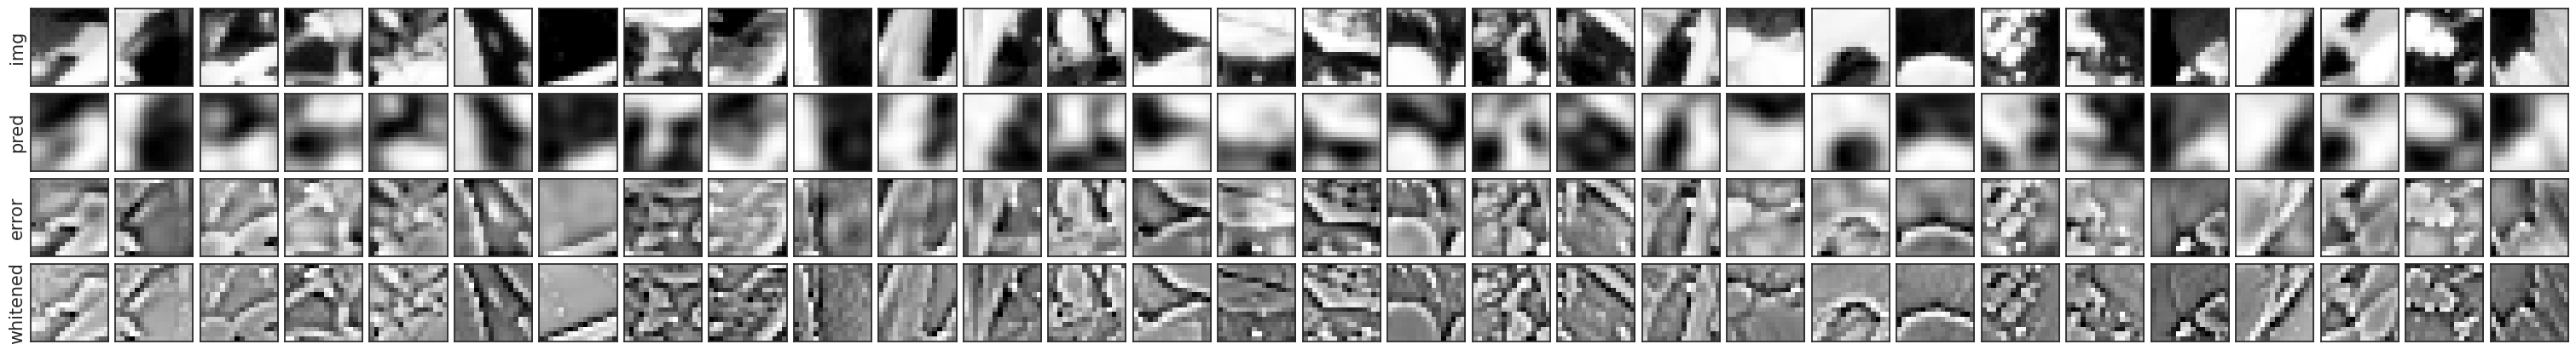

In [62]:
for t in range(30):
    print(f"t = {t}")
    conditional = output['conditional'][str(t)]
    pred = conditional.loc
    error = true - pred

    _plot_selected_samples(select_from=range(500))

In [65]:
corrs = []
for t in range(1000):
    conditional = output['conditional'][str(t)]
    pred = conditional.loc

    corr = sp_stats.pearsonr(
        tonp(pred.ravel()),
        tonp(whitened.ravel()),
    )
    corrs.append(corr.statistic)

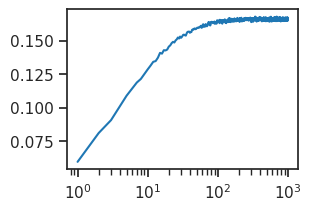

In [70]:
fig, ax = create_figure()
ax.plot(range(1, len(corrs) + 1),  corrs)
ax.set(xscale='log')
plt.show()

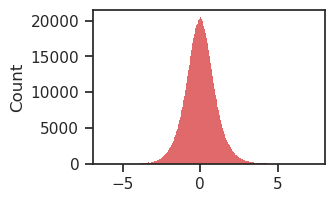

In [25]:
tmp = tonp(tmp.ravel())
sns.histplot(tmp, color='C3');

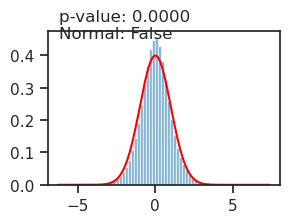

Shapiro-Wilk test: statistic=0.9938, p-value=0.0000

Data is not normal

In [30]:
mean = np.mean(tmp)
std = np.std(tmp)

# Fit Gaussian
x = np.linspace(min(tmp), max(tmp), 1000)
pdf = sp_stats.norm.pdf(x, mean, std)

# Test normality (null hypothesis: data comes from normal distribution)
stat, p = sp_stats.shapiro(tmp)
is_normal = p > 0.05

# Visualization
plt.hist(tmp, density=True, alpha=0.6, bins=70)
plt.plot(x, pdf, 'r-')
plt.text(0.05, 0.95, f'p-value: {p:.4f}\nNormal: {is_normal}', transform=plt.gca().transAxes)
plt.show()

print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p:.4f}")
print(f"Data is {'likely normal' if is_normal else 'not normal'}")